In [111]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
from scipy.stats import ttest_ind, ks_2samp
import warnings

In [2]:
xr.__version__

'2023.5.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
# rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
# rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 18
Number of W files (D2): 18
Number of ENV files (D2): 18
Number of stats files (D3): 18
Number of W files (D3): 18
Number of ENV files (D3): 18
Number of stats files (D4): 18
Number of W files (D4): 18
Number of ENV files (D4): 18


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181219/eda09/base//d2/sta

## Read & combine data files

In [7]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
# dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 6498


<xarray.Dataset>
Dimensions:                  (tracks: 6498, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 6494 6495 6496 6497
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/189)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [8]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
# dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 11051


<xarray.Dataset>
Dimensions:                  (tracks: 11051, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 ... 11047 11048 11049 11050
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/189)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [9]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO D4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
# dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

Number of tracks (D4): 8824


<xarray.Dataset>
Dimensions:                  (tracks: 8824, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 8820 8821 8822 8823
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/183)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Subset tracks

In [10]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
height = ds_d2.z / 1000.

In [11]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
lifetime_d2 = (ds_d2['track_duration'] * time_res).load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)) & \
                    (lifetime_d2 >= min(lifetime_range) & (lifetime_d2 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 3567


In [12]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
lifetime_d3 = (ds_d3['track_duration'] * time_res).load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)) & \
                    (lifetime_d3 >= min(lifetime_range) & (lifetime_d3 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 5932


In [13]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
lifetime_d4 = (ds_d4['track_duration'] * time_res).load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)) & \
                    (lifetime_d4 >= min(lifetime_range) & (lifetime_d4 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 5336


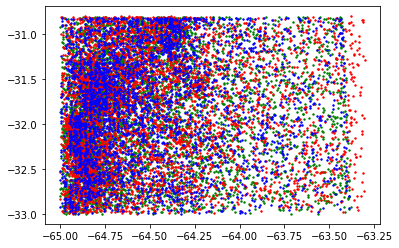

In [14]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [15]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-64.99961 -63.304028 -32.998272 -30.800056
[-65.0, -63.3] [-33.0, -30.8]


## Find merge/split track indices

In [16]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [17]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

In [18]:
# ntracks_nms_d2 = np.count_nonzero(tid_d2['nms'] == True)
# ntracks_ns_d2 = np.count_nonzero(tid_d2['ns'] == True)
# print(f'D2 non-merge-split tracks: {ntracks_nms_d2}, non-split tracks: {ntracks_ns_d2}')

In [19]:
# ntracks_nms_d3 = np.count_nonzero(tid_d3['nms'] == True)
# ntracks_ns_d3 = np.count_nonzero(tid_d3['ns'] == True)
# print(f'D3 non-merge-split tracks: {ntracks_nms_d3}, non-split tracks: {ntracks_ns_d3}')

In [20]:
# ntracks_nms_d4 = np.count_nonzero(tid_d4['nms'] == True)
# ntracks_ns_d4 = np.count_nonzero(tid_d4['ns'] == True)
# print(f'D4 non-merge-split tracks: {ntracks_nms_d4}, non-split tracks: {ntracks_ns_d4}')

## Subset DataSets with non-merge/non-split tracks

In [21]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 1271
D3 non-merge-split tracks: 2553
D4 non-merge-split tracks: 2697


## Subset DataSets with non-split tracks

In [22]:
dsns_d2 = ds_d2.isel(tracks=tid_d2['ns'])
dsns_d3 = ds_d3.isel(tracks=tid_d3['ns'])
dsns_d4 = ds_d4.isel(tracks=tid_d4['ns'])

ntracks_ns_d2 = dsns_d2.sizes['tracks']
ntracks_ns_d3 = dsns_d3.sizes['tracks']
ntracks_ns_d4 = dsns_d4.sizes['tracks']
print(f'D2 non-split tracks: {ntracks_ns_d2}')
print(f'D3 non-split tracks: {ntracks_ns_d3}')
print(f'D4 non-split tracks: {ntracks_ns_d4}')

D2 non-split tracks: 1898
D3 non-split tracks: 3490
D4 non-split tracks: 3487


In [23]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.dims['times']
nz = dsnms_d2.dims['z']
ncores = dsnms_d2.dims['core']

time_res = 5.0  # [min]
xtime = dsnms_d2.times * time_res
height = dsnms_d2.z / 1000.

In [24]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dsnms_d2['track_duration'].load() * time_res
track_lifetime_d3 = dsnms_d3['track_duration'].load() * time_res
track_lifetime_d4 = dsnms_d4['track_duration'].load() * time_res

# Cell max reflectivity
maxdbz_d2 = dsnms_d2['max_dbz'].load()
maxdbz_d3 = dsnms_d3['max_dbz'].load()
maxdbz_d4 = dsnms_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsnms_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsnms_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsnms_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsnms_d2['cell_area'].load()
cellarea_d3 = dsnms_d3['cell_area'].load()
cellarea_d4 = dsnms_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

In [25]:
# # Get preCI environmental variables
# ntimes_preCI = 12
# # Convert MU EL(LNB) height to [km]
# MULNB_d2 = dsnms_d2.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# MULNB_d3 = dsnms_d3.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# MULNB_d4 = dsnms_d4.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000

# MUCAPE_d2 = dsnms_d2.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
# MUCAPE_d3 = dsnms_d3.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
# MUCAPE_d4 = dsnms_d4.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))

In [26]:
# Get preCI MU LNB
preCI_time = -3  # preCI time
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d2 = (dsnms_d2.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d3 = (dsnms_d3.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d4 = (dsnms_d4.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)

(array([0.0007516 , 0.        , 0.00150319, 0.00225479, 0.0007516 ,
        0.0007516 , 0.00601278, 0.00977076, 0.01052236, 0.00526118,
        0.00977076, 0.00826757, 0.00601278, 0.01803833, 0.06914694,
        0.12100714, 0.16009019, 0.19391206, 0.15633221, 0.06538895,
        0.01653514, 0.03532507, 0.06012777, 0.06839534, 0.11724915,
        0.16384818, 0.13829387, 0.16009019, 0.14430665, 0.11724915,
        0.08793687, 0.04509583]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ]),
 <BarContainer object of 32 artists>)

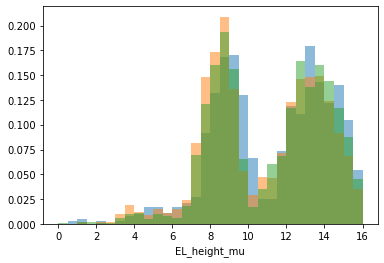

In [27]:
bins = np.arange(0, 16.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [28]:
# bins = np.arange(0, 6000.1, 200)
# MUCAPE_d2.sel(times=-3).plot.hist(bins=bins, alpha=0.5, label='D2')
# MUCAPE_d3.sel(times=-3).plot.hist(bins=bins, alpha=0.5, label='D3')
# MUCAPE_d4.sel(times=-3).plot.hist(bins=bins, alpha=0.5, label='D4')

In [29]:
# bins = np.arange(5,200,5)
# track_lifetime_d2.plot.hist(bins=bins, alpha=0.5, label='D2')
# track_lifetime_d3.plot.hist(bins=bins, alpha=0.5, label='D3')
# track_lifetime_d4.plot.hist(bins=bins, alpha=0.5, label='D4')
# plt.legend()

In [30]:
# bins = np.arange(2, 31, 2)
# celldiam_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
# celldiam_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
# celldiam_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')

In [31]:
# bins = np.arange(2,16,1)
# maxETH_10dbz_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
# maxETH_10dbz_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
# maxETH_10dbz_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')
# plt.legend()

## Get lifetime-max 10dBZ ETH and cell diameter percentile values

In [32]:
ETH_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.   4.75 6.  ]
Max CellDiam percentile values (D2): [ 9.7720499  10.17107201 11.96826839]


In [33]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.25 6.   7.  ]
Max CellDiam percentile values (D3): [4.95074368 5.58519173 6.635397  ]


In [34]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  5.5 6.5]
Max CellDiam percentile values (D4): [4.90810179 5.41151619 6.28254938]


## Plot cell diameter & ETH PDF with narrow & wide cell cutoffs

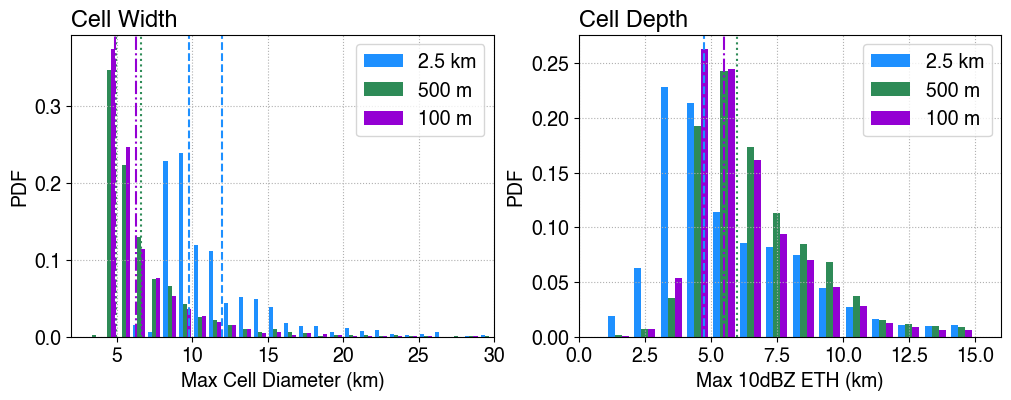

In [35]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.family'] = 'Helvetica'

fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

ax = axes[0]
bins = np.arange(2, 31, 1)
bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
bar_labels = list(name_map.values())
bar_colors = list(lcolors.values())
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
ax.legend()
# Percentile lines
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.set_xlim((2,30))
ax.set_xlabel('Max Cell Diameter (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Width', loc='left')
ax.grid(ls=':')

ax = axes[1]
bins = np.arange(0, 16, 1)
bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# Percentile lines
ax.axvline(max10dbz_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(max10dbz_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(max10dbz_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.legend()
ax.set_xlim((0,16))
ax.set_xlabel('Max 10dBZ ETH (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Depth', loc='left')
ax.grid(ls=':')

figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Separate narrow vs. wide cell DataSets

In [36]:
MULNB_d2.shape, trackmaxCellDiam_d2.shape

((1271,), (1271,))

In [37]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]

In [38]:
# Define narrow vs. wide thresholds
narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=0.33).item()
wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=0.66).item()
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.01f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.01f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 <= narrow_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.max_dbz.max(dim='times')
wide_maxdbz_d2 = ds_wide_d2.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')

Narrow diameter threshold (D2): 9.8 km
Wide diameter threshold (D2): 12.0 km
Number of narrow cells (D2): 588
Number of wide cells (D2): 446


In [39]:
# Define narrow vs. wide thresholds
narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=0.33).item()
wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=0.66).item()
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.01f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.01f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 <= narrow_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.max_dbz.max(dim='times')
wide_maxdbz_d3 = ds_wide_d3.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')

Narrow diameter threshold (D3): 5.0 km
Wide diameter threshold (D3): 6.6 km
Number of narrow cells (D3): 824
Number of wide cells (D3): 823


In [40]:
# Define narrow vs. wide thresholds
narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=0.33).item()
wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=0.66).item()
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.01f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.01f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 <= narrow_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.max_dbz.max(dim='times')
wide_maxdbz_d4 = ds_wide_d4.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')

Narrow diameter threshold (D4): 4.9 km
Wide diameter threshold (D4): 6.3 km
Number of narrow cells (D4): 866
Number of wide cells (D4): 875


## Get environmental parameters for narrow vs. wide cells

In [41]:
# Number of times preCI
ntimes_preCI = 13

# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d2 = (ds_narrow_d2.pEL_height_mu).sel(times=slice(-1*ntimes_preCI,0))/1000
narrow_pCAPEmu_d2 = ds_narrow_d2.pCAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_pCAPEacbl_d2 = ds_narrow_d2.pCAPEacbl_ml.sel(times=slice(-1*ntimes_preCI,0))
narrow_pCINmu_d2 = ds_narrow_d2.pCIN_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_LCLz_d2 = ds_narrow_d2.LCL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
narrow_LCLt_d2 = ds_narrow_d2.LCL_temp_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_pLFCz_d2 = ds_narrow_d2.pLFC_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# Moisture
narrow_RHacbl_d2 = ds_narrow_d2.RH_mean_ACBL.sel(times=slice(-1*ntimes_preCI,0))
narrow_RH600mb_d2 = ds_narrow_d2.rh_600mb.sel(times=slice(-1*ntimes_preCI,0))
narrow_RH500mb_d2 = ds_narrow_d2.rh_500mb.sel(times=slice(-1*ntimes_preCI,0))
narrow_RHlfc1500_d2 = ds_narrow_d2.rh_at_pmuLFCplus1500m.sel(times=slice(-1*ntimes_preCI,0))
narrow_PW_d2 = ds_narrow_d2.PW.sel(times=slice(-1*ntimes_preCI,0))
# Wind shear
narrow_BWSacbl_d2 = ds_narrow_d2.shear_mag_bulk_ACBL_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_BWS03km_d2 = ds_narrow_d2.shear_mag_bulk_0to3km.sel(times=slice(-1*ntimes_preCI,0))
narrow_BWS06km_d2 = ds_narrow_d2.shear_mag_bulk_0to6km.sel(times=slice(-1*ntimes_preCI,0))

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d2 = (ds_wide_d2.pEL_height_mu).sel(times=slice(-1*ntimes_preCI,0))/1000
wide_pCAPEmu_d2 = ds_wide_d2.pCAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_pCAPEacbl_d2 = ds_wide_d2.pCAPEacbl_ml.sel(times=slice(-1*ntimes_preCI,0))
wide_pCINmu_d2 = ds_wide_d2.pCIN_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_LCLz_d2 = ds_wide_d2.LCL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
wide_LCLt_d2 = ds_wide_d2.LCL_temp_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_pLFCz_d2 = ds_wide_d2.pLFC_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# Moisture
wide_RHacbl_d2 = ds_wide_d2.RH_mean_ACBL.sel(times=slice(-1*ntimes_preCI,0))
wide_RH600mb_d2 = ds_wide_d2.rh_600mb.sel(times=slice(-1*ntimes_preCI,0))
wide_RH500mb_d2 = ds_wide_d2.rh_500mb.sel(times=slice(-1*ntimes_preCI,0))
wide_RHlfc1500_d2 = ds_wide_d2.rh_at_pmuLFCplus1500m.sel(times=slice(-1*ntimes_preCI,0))
wide_PW_d2 = ds_wide_d2.PW.sel(times=slice(-1*ntimes_preCI,0))
# Wind shear
wide_BWSacbl_d2 = ds_wide_d2.shear_mag_bulk_ACBL_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_BWS03km_d2 = ds_wide_d2.shear_mag_bulk_0to3km.sel(times=slice(-1*ntimes_preCI,0))
wide_BWS06km_d2 = ds_wide_d2.shear_mag_bulk_0to6km.sel(times=slice(-1*ntimes_preCI,0))

In [42]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d3 = ds_narrow_d3.pEL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
narrow_pCAPEmu_d3 = ds_narrow_d3.pCAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_pCAPEacbl_d3 = ds_narrow_d3.pCAPEacbl_ml.sel(times=slice(-1*ntimes_preCI,0))
narrow_pCINmu_d3 = ds_narrow_d3.pCIN_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_LCLz_d3 = ds_narrow_d3.LCL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
narrow_LCLt_d3 = ds_narrow_d3.LCL_temp_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_pLFCz_d3 = ds_narrow_d3.pLFC_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# Moisture
narrow_RHacbl_d3 = ds_narrow_d3.RH_mean_ACBL.sel(times=slice(-1*ntimes_preCI,0))
narrow_RH600mb_d3 = ds_narrow_d3.rh_600mb.sel(times=slice(-1*ntimes_preCI,0))
narrow_RH500mb_d3 = ds_narrow_d3.rh_500mb.sel(times=slice(-1*ntimes_preCI,0))
narrow_RHlfc1500_d3 = ds_narrow_d3.rh_at_pmuLFCplus1500m.sel(times=slice(-1*ntimes_preCI,0))
narrow_PW_d3 = ds_narrow_d3.PW.sel(times=slice(-1*ntimes_preCI,0))
# Wind shear
narrow_BWSacbl_d3 = ds_narrow_d3.shear_mag_bulk_ACBL_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_BWS03km_d3 = ds_narrow_d3.shear_mag_bulk_0to3km.sel(times=slice(-1*ntimes_preCI,0))
narrow_BWS06km_d3 = ds_narrow_d3.shear_mag_bulk_0to6km.sel(times=slice(-1*ntimes_preCI,0))

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d3 = ds_wide_d3.pEL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
wide_pCAPEmu_d3 = ds_wide_d3.pCAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_pCAPEacbl_d3 = ds_wide_d3.pCAPEacbl_ml.sel(times=slice(-1*ntimes_preCI,0))
wide_pCINmu_d3 = ds_wide_d3.pCIN_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_LCLz_d3 = ds_wide_d3.LCL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
wide_LCLt_d3 = ds_wide_d3.LCL_temp_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_pLFCz_d3 = ds_wide_d3.pLFC_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# Moisture
wide_RHacbl_d3 = ds_wide_d3.RH_mean_ACBL.sel(times=slice(-1*ntimes_preCI,0))
wide_RH600mb_d3 = ds_wide_d3.rh_600mb.sel(times=slice(-1*ntimes_preCI,0))
wide_RH500mb_d3 = ds_wide_d3.rh_500mb.sel(times=slice(-1*ntimes_preCI,0))
wide_RHlfc1500_d3 = ds_wide_d3.rh_at_pmuLFCplus1500m.sel(times=slice(-1*ntimes_preCI,0))
wide_PW_d3 = ds_wide_d3.PW.sel(times=slice(-1*ntimes_preCI,0))
# Wind shear
wide_BWSacbl_d3 = ds_wide_d3.shear_mag_bulk_ACBL_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_BWS03km_d3 = ds_wide_d3.shear_mag_bulk_0to3km.sel(times=slice(-1*ntimes_preCI,0))
wide_BWS06km_d3 = ds_wide_d3.shear_mag_bulk_0to6km.sel(times=slice(-1*ntimes_preCI,0))

In [43]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d4 = ds_narrow_d4.pEL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
narrow_pCAPEmu_d4 = ds_narrow_d4.pCAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_pCAPEacbl_d4 = ds_narrow_d4.pCAPEacbl_ml.sel(times=slice(-1*ntimes_preCI,0))
narrow_pCINmu_d4 = ds_narrow_d4.pCIN_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_LCLz_d4 = ds_narrow_d4.LCL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
narrow_LCLt_d4 = ds_narrow_d4.LCL_temp_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_pLFCz_d4 = ds_narrow_d4.pLFC_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# Moisture
narrow_RHacbl_d4 = ds_narrow_d4.RH_mean_ACBL.sel(times=slice(-1*ntimes_preCI,0))
narrow_RH600mb_d4 = ds_narrow_d4.rh_600mb.sel(times=slice(-1*ntimes_preCI,0))
narrow_RH500mb_d4 = ds_narrow_d4.rh_500mb.sel(times=slice(-1*ntimes_preCI,0))
narrow_RHlfc1500_d4 = ds_narrow_d4.rh_at_pmuLFCplus1500m.sel(times=slice(-1*ntimes_preCI,0))
narrow_PW_d4 = ds_narrow_d4.PW.sel(times=slice(-1*ntimes_preCI,0))
# Wind shear
narrow_BWSacbl_d4 = ds_narrow_d4.shear_mag_bulk_ACBL_mu.sel(times=slice(-1*ntimes_preCI,0))
narrow_BWS03km_d4 = ds_narrow_d4.shear_mag_bulk_0to3km.sel(times=slice(-1*ntimes_preCI,0))
narrow_BWS06km_d4 = ds_narrow_d4.shear_mag_bulk_0to6km.sel(times=slice(-1*ntimes_preCI,0))

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d4 = ds_wide_d4.pEL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
wide_pCAPEmu_d4 = ds_wide_d4.pCAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_pCAPEacbl_d4 = ds_wide_d4.pCAPEacbl_ml.sel(times=slice(-1*ntimes_preCI,0))
wide_pCINmu_d4 = ds_wide_d4.pCIN_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_LCLz_d4 = ds_wide_d4.LCL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
wide_LCLt_d4 = ds_wide_d4.LCL_temp_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_pLFCz_d4 = ds_wide_d4.pLFC_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# Moisture
wide_RHacbl_d4 = ds_wide_d4.RH_mean_ACBL.sel(times=slice(-1*ntimes_preCI,0))
wide_RH600mb_d4 = ds_wide_d4.rh_600mb.sel(times=slice(-1*ntimes_preCI,0))
wide_RH500mb_d4 = ds_wide_d4.rh_500mb.sel(times=slice(-1*ntimes_preCI,0))
wide_RHlfc1500_d4 = ds_wide_d4.rh_at_pmuLFCplus1500m.sel(times=slice(-1*ntimes_preCI,0))
wide_PW_d4 = ds_wide_d4.PW.sel(times=slice(-1*ntimes_preCI,0))
# Wind shear
wide_BWSacbl_d4 = ds_wide_d4.shear_mag_bulk_ACBL_mu.sel(times=slice(-1*ntimes_preCI,0))
wide_BWS03km_d4 = ds_wide_d4.shear_mag_bulk_0to3km.sel(times=slice(-1*ntimes_preCI,0))
wide_BWS06km_d4 = ds_wide_d4.shear_mag_bulk_0to6km.sel(times=slice(-1*ntimes_preCI,0))

In [ ]:
# bins_el = np.arange(0, 20.1, 1)
# narrow_MUEL_d2.sel(times=-3).plot.hist(bins=bins_el, density=True, alpha=0.5)
# wide_MUEL_d2.sel(times=-3).plot.hist(bins=bins_el, density=True, alpha=0.5)

In [59]:
narrow_maxdbz_d2.mean()

<xarray.DataArray 'max_dbz' ()>
array(24.294931, dtype=float32)

/tmp/ipykernel_3842395/4151023521.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


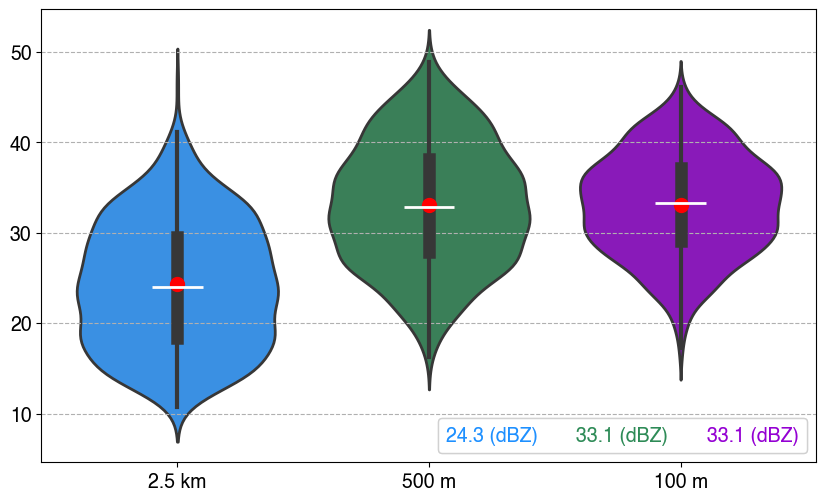

In [76]:
data = [narrow_maxdbz_d2.data, narrow_maxdbz_d3.data, narrow_maxdbz_d4.data]
avg2 = narrow_maxdbz_d2.mean().values
avg3 = narrow_maxdbz_d3.mean().values
avg4 = narrow_maxdbz_d4.mean().values
med2 = narrow_maxdbz_d2.median().values
med3 = narrow_maxdbz_d3.median().values
med4 = narrow_maxdbz_d4.median().values
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
palette = list(lcolors.values())
lw_kde = 2
color_avg = 'red'
color_med = 'white'
xlabels = list(name_map.values())
leg_fontsize = None
leg_units = 'dBZ'

fig, ax = plt.subplots(1,1,figsize=(10,6),dpi=100)
data[0]
vp = sns.violinplot(data=data, ax=ax, palette=palette, linewidth=lw_kde)
# Plot median value as line
ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
# Plot mean value as circle
ax.scatter(0, avg2, color=color_avg, s=100, zorder=3)
ax.scatter(1, avg3, color=color_avg, s=100, zorder=3)
ax.scatter(2, avg4, color=color_avg, s=100, zorder=3)
ax.grid(ls='--', axis='y')
ax.set_xticklabels(xlabels)
# ax.set_ylabel(ylabel)

legend_avg = [mpl.lines.Line2D([0], [0], color=lcolors['d2'], ls='none', label=f'{avg2:.1f}'+f' ({leg_units})'),
              mpl.lines.Line2D([0], [0], color=lcolors['d3'], ls='none', label=f'{avg3:.1f}'+f' ({leg_units})'),
              mpl.lines.Line2D([0], [0], color=lcolors['d4'], ls='none', label=f'{avg4:.1f}'+f' ({leg_units})'),]
legend = ax.legend(handles=legend_avg, handlelength=0, handletextpad=0, loc='lower right', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
ax.add_artist(legend)

In [125]:
def kstest_data(data1, data2, name, alpha=0.05):
    # compare samples
    stat, p = ks_2samp(data1, data2)
    # interpret
    # alpha = 0.05
    if p > alpha:
        print(f'{name}: Same distributions')
        sig = '$\\times$'
    else:
        print(f'{name}: Different distributions')
        sig = '$\checkmark$'
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    return sig

In [127]:
# Significance level (P value)
alpha = 0.01
# Lifetime
narrow_sig_lifetime23 = kstest_data(narrow_track_lifetime_d2.data[~np.isnan(narrow_track_lifetime_d2)], 
                                     narrow_track_lifetime_d3.data[~np.isnan(narrow_track_lifetime_d3)], 'Narrow Cell Lifetime D2 vs. D3', alpha=alpha)
narrow_sig_lifetime24 = kstest_data(narrow_track_lifetime_d2.data[~np.isnan(narrow_track_lifetime_d2)], 
                                     narrow_track_lifetime_d4.data[~np.isnan(narrow_track_lifetime_d4)], 'Narrow Cell Lifetime D2 vs. D4', alpha=alpha)
narrow_sig_lifetime34 = kstest_data(narrow_track_lifetime_d3.data[~np.isnan(narrow_track_lifetime_d3)], 
                                     narrow_track_lifetime_d4.data[~np.isnan(narrow_track_lifetime_d4)], 'Narrow Cell Lifetime D3 vs. D4', alpha=alpha)
# Max reflectivity
narrow_sig_maxdbz23 = kstest_data(narrow_maxdbz_d2.data[~np.isnan(narrow_maxdbz_d2)], 
                                     narrow_maxdbz_d3.data[~np.isnan(narrow_maxdbz_d3)], 'Narrow Cell maxdbz D2 vs. D3', alpha=alpha)
narrow_sig_maxdbz24 = kstest_data(narrow_maxdbz_d2.data[~np.isnan(narrow_maxdbz_d2)], 
                                     narrow_maxdbz_d4.data[~np.isnan(narrow_maxdbz_d4)], 'Narrow Cell maxdbz D2 vs. D4', alpha=alpha)
narrow_sig_maxdbz34 = kstest_data(narrow_maxdbz_d3.data[~np.isnan(narrow_maxdbz_d3)], 
                                     narrow_maxdbz_d4.data[~np.isnan(narrow_maxdbz_d4)], 'Narrow Cell maxdbz D3 vs. D4', alpha=alpha)
# Max ETH
narrow_sig_maxETH10dbz23 = kstest_data(narrow_maxETH10dbz_d2.data[~np.isnan(narrow_maxETH10dbz_d2)], 
                                     narrow_maxETH10dbz_d3.data[~np.isnan(narrow_maxETH10dbz_d3)], 'Narrow Cell maxETH10dbz D2 vs. D3', alpha=alpha)
narrow_sig_maxETH10dbz24 = kstest_data(narrow_maxETH10dbz_d2.data[~np.isnan(narrow_maxETH10dbz_d2)], 
                                     narrow_maxETH10dbz_d4.data[~np.isnan(narrow_maxETH10dbz_d4)], 'Narrow Cell maxETH10dbz D2 vs. D4', alpha=alpha)
narrow_sig_maxETH10dbz34 = kstest_data(narrow_maxETH10dbz_d3.data[~np.isnan(narrow_maxETH10dbz_d3)], 
                                     narrow_maxETH10dbz_d4.data[~np.isnan(narrow_maxETH10dbz_d4)], 'Narrow Cell maxETH10dbz D3 vs. D4', alpha=alpha)

# Lifetime
wide_sig_lifetime23 = kstest_data(wide_track_lifetime_d2.data[~np.isnan(wide_track_lifetime_d2)], 
                                     wide_track_lifetime_d3.data[~np.isnan(wide_track_lifetime_d3)], 'Wide Cell Lifetime D2 vs. D3', alpha=alpha)
wide_sig_lifetime24 = kstest_data(wide_track_lifetime_d2.data[~np.isnan(wide_track_lifetime_d2)], 
                                     wide_track_lifetime_d4.data[~np.isnan(wide_track_lifetime_d4)], 'Wide Cell Lifetime D2 vs. D4', alpha=alpha)
wide_sig_lifetime34 = kstest_data(wide_track_lifetime_d3.data[~np.isnan(wide_track_lifetime_d3)], 
                                     wide_track_lifetime_d4.data[~np.isnan(wide_track_lifetime_d4)], 'Wide Cell Lifetime D3 vs. D4', alpha=alpha)
# Max reflectivity
wide_sig_maxdbz23 = kstest_data(wide_maxdbz_d2.data[~np.isnan(wide_maxdbz_d2)], 
                                     wide_maxdbz_d3.data[~np.isnan(wide_maxdbz_d3)], 'Wide Cell maxdbz D2 vs. D3', alpha=alpha)
wide_sig_maxdbz24 = kstest_data(wide_maxdbz_d2.data[~np.isnan(wide_maxdbz_d2)], 
                                     wide_maxdbz_d4.data[~np.isnan(wide_maxdbz_d4)], 'Wide Cell maxdbz D2 vs. D4', alpha=alpha)
wide_sig_maxdbz34 = kstest_data(wide_maxdbz_d3.data[~np.isnan(wide_maxdbz_d3)], 
                                     wide_maxdbz_d4.data[~np.isnan(wide_maxdbz_d4)], 'Wide Cell maxdbz D3 vs. D4', alpha=alpha)
# Max ETH
wide_sig_maxETH10dbz23 = kstest_data(wide_maxETH10dbz_d2.data[~np.isnan(wide_maxETH10dbz_d2)], 
                                     wide_maxETH10dbz_d3.data[~np.isnan(wide_maxETH10dbz_d3)], 'Wide Cell maxETH10dbz D2 vs. D3', alpha=alpha)
wide_sig_maxETH10dbz24 = kstest_data(wide_maxETH10dbz_d2.data[~np.isnan(wide_maxETH10dbz_d2)], 
                                     wide_maxETH10dbz_d4.data[~np.isnan(wide_maxETH10dbz_d4)], 'Wide Cell maxETH10dbz D2 vs. D4', alpha=alpha)
wide_sig_maxETH10dbz34 = kstest_data(wide_maxETH10dbz_d3.data[~np.isnan(wide_maxETH10dbz_d3)], 
                                     wide_maxETH10dbz_d4.data[~np.isnan(wide_maxETH10dbz_d4)], 'Wide Cell maxETH10dbz D3 vs. D4', alpha=alpha)

## Function to plot nrow x ncol of violin plot

In [133]:
def plot_mxn_violin(nrow, ncol, da, sigtest=None, ypos_sig=None, ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    palette = list(lcolors.values())    
    lw_kde = 2
    size_avg = 60
    color_avg = 'red'
    color_med = 'white'
    xlabels = list(name_map.values())
    leg_fontsize = None
    # leg_units = 'dBZ'
    
    # bar_labels = list(name_map.values())
    # bar_colors = list(lcolors.values())
       
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            violin_data = da[row][col]
            # Calculate means and medians
            avg2 = np.nanmean(violin_data[0])
            avg3 = np.nanmean(violin_data[1])
            avg4 = np.nanmean(violin_data[2])
            med2 = np.nanmedian(violin_data[0])
            med3 = np.nanmedian(violin_data[1])
            med4 = np.nanmedian(violin_data[2])
            # Violin plot
            vp = sns.violinplot(data=violin_data, ax=ax, palette=palette, linewidth=lw_kde)
            # Plot median value as line
            ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
            # Plot mean value as circle
            ax.scatter(0, avg2, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(1, avg3, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(2, avg4, color=color_avg, s=size_avg, zorder=3)
            # Set plots
            ax.set_xticklabels(xlabels)
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            if ylims is not None: ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if sigtest is not None:
                ax.text(0.05, ypos_sig[row][col], sigtest[row][col]['d2'], color=color_avg, va='top', fontsize=leg_fontsize)
                ax.text(1.05, ypos_sig[row][col], sigtest[row][col]['d3'], color=color_avg, va='top', fontsize=leg_fontsize)
            # # Legend
            # legend_avg = [mpl.lines.Line2D([0], [0], color=lcolors['d2'], ls='none', label=f'{avg2:.1f}'+f' ({leg_units})'),
            #                 mpl.lines.Line2D([0], [0], color=lcolors['d3'], ls='none', label=f'{avg3:.1f}'+f' ({leg_units})'),
            #                 mpl.lines.Line2D([0], [0], color=lcolors['d4'], ls='none', label=f'{avg4:.1f}'+f' ({leg_units})'),]
            # legend = ax.legend(handles=legend_avg, handlelength=0, handletextpad=0, loc='lower right', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
            # ax.add_artist(legend)
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


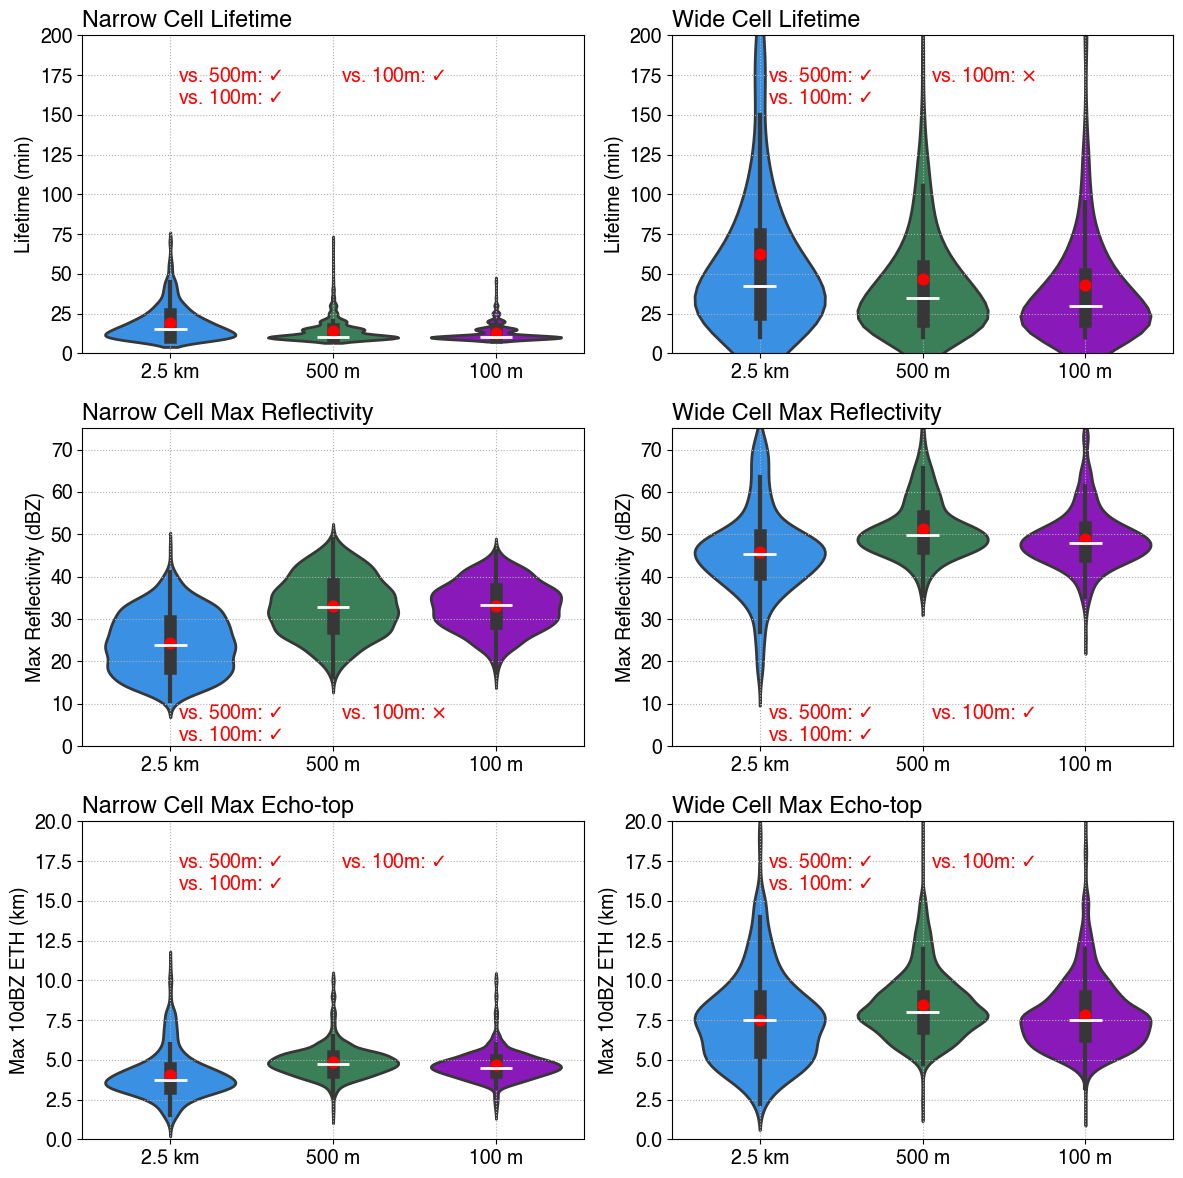

In [135]:
data_arr = [
    [[narrow_track_lifetime_d2.data, narrow_track_lifetime_d3.data, narrow_track_lifetime_d4.data],[wide_track_lifetime_d2.data, wide_track_lifetime_d3.data, wide_track_lifetime_d4.data]],
    [[narrow_maxdbz_d2.data, narrow_maxdbz_d3.data, narrow_maxdbz_d4.data],[wide_maxdbz_d2.data, wide_maxdbz_d3.data, wide_maxdbz_d4.data]],
    [[narrow_maxETH10dbz_d2.data, narrow_maxETH10dbz_d3.data, narrow_maxETH10dbz_d4.data],[wide_maxETH10dbz_d2.data, wide_maxETH10dbz_d3.data, wide_maxETH10dbz_d4.data]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_lifetime23+'\n'+'vs. 100m: '+narrow_sig_lifetime23, 'd3':'vs. 100m: '+narrow_sig_lifetime34},
     {'d2':'vs. 500m: '+wide_sig_lifetime23+'\n'+'vs. 100m: '+wide_sig_lifetime23, 'd3':'vs. 100m: '+wide_sig_lifetime34},],
    [{'d2':'vs. 500m: '+narrow_sig_maxdbz23+'\n'+'vs. 100m: '+narrow_sig_maxdbz23, 'd3':'vs. 100m: '+narrow_sig_maxdbz34},
     {'d2':'vs. 500m: '+wide_sig_maxdbz23+'\n'+'vs. 100m: '+wide_sig_maxdbz23, 'd3':'vs. 100m: '+wide_sig_maxdbz34},],
    [{'d2':'vs. 500m: '+narrow_sig_maxETH10dbz23+'\n'+'vs. 100m: '+narrow_sig_maxETH10dbz23, 'd3':'vs. 100m: '+narrow_sig_maxETH10dbz34},
     {'d2':'vs. 500m: '+wide_sig_maxETH10dbz23+'\n'+'vs. 100m: '+wide_sig_maxETH10dbz23, 'd3':'vs. 100m: '+wide_sig_maxETH10dbz34},],
]
ypos_sig = [[180]*2, [10]*2, [18]*2]
titles = [['Narrow Cell Lifetime','Wide Cell Lifetime'], ['Narrow Cell Max Reflectivity','Wide Cell Max Reflectivity'], ['Narrow Cell Max Echo-top', 'Wide Cell Max Echo-top']]
ylabels = [['Lifetime (min)']*2, ['Max Reflectivity (dBZ)']*2, ['Max 10dBZ ETH (km)']*2, ]
ylims = [[(0,200)]*2, [(0,75)]*2, [(0,20)]*2]
xlabels = None
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
fontsize = 14
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_Lifetime_maxRefl_maxETH10dBZ_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [147]:
# MU LNB
narrow_sig_pELmu23 = kstest_data(narrow_pELmu_d2.values[~np.isnan(narrow_pELmu_d2)], 
                                     narrow_pELmu_d3.values[~np.isnan(narrow_pELmu_d3)], 'Narrow Cell pELmu D2 vs. D3', alpha=alpha)
narrow_sig_pELmu24 = kstest_data(narrow_pELmu_d2.values[~np.isnan(narrow_pELmu_d2)], 
                                     narrow_pELmu_d4.values[~np.isnan(narrow_pELmu_d4)], 'Narrow Cell pELmu D2 vs. D4', alpha=alpha)
narrow_sig_pELmu34 = kstest_data(narrow_pELmu_d3.values[~np.isnan(narrow_pELmu_d3)], 
                                     narrow_pELmu_d4.values[~np.isnan(narrow_pELmu_d4)], 'Narrow Cell pELmu D3 vs. D4', alpha=alpha)
# MU CAPE
narrow_sig_pCAPEmu23 = kstest_data(narrow_pCAPEmu_d2.values[~np.isnan(narrow_pCAPEmu_d2)], 
                                     narrow_pCAPEmu_d3.values[~np.isnan(narrow_pCAPEmu_d3)], 'Narrow Cell pCAPEmu D2 vs. D3', alpha=alpha)
narrow_sig_pCAPEmu24 = kstest_data(narrow_pCAPEmu_d2.values[~np.isnan(narrow_pCAPEmu_d2)], 
                                     narrow_pCAPEmu_d4.values[~np.isnan(narrow_pCAPEmu_d4)], 'Narrow Cell pCAPEmu D2 vs. D4', alpha=alpha)
narrow_sig_pCAPEmu34 = kstest_data(narrow_pCAPEmu_d3.values[~np.isnan(narrow_pCAPEmu_d3)], 
                                     narrow_pCAPEmu_d4.values[~np.isnan(narrow_pCAPEmu_d4)], 'Narrow Cell pCAPEmu D3 vs. D4', alpha=alpha)
# ACBL CAPE
narrow_sig_pCAPEacbl23 = kstest_data(narrow_pCAPEacbl_d2.values[~np.isnan(narrow_pCAPEacbl_d2)], 
                                     narrow_pCAPEacbl_d3.values[~np.isnan(narrow_pCAPEacbl_d3)], 'Narrow Cell pCAPEacbl D2 vs. D3', alpha=alpha)
narrow_sig_pCAPEacbl24 = kstest_data(narrow_pCAPEacbl_d2.values[~np.isnan(narrow_pCAPEacbl_d2)], 
                                     narrow_pCAPEacbl_d4.values[~np.isnan(narrow_pCAPEacbl_d4)], 'Narrow Cell pCAPEacbl D2 vs. D4', alpha=alpha)
narrow_sig_pCAPEacbl34 = kstest_data(narrow_pCAPEacbl_d3.values[~np.isnan(narrow_pCAPEacbl_d3)], 
                                     narrow_pCAPEacbl_d4.values[~np.isnan(narrow_pCAPEacbl_d4)], 'Narrow Cell pCAPEacbl D3 vs. D4', alpha=alpha)
# MU CIN
narrow_sig_pCINmu23 = kstest_data(narrow_pCINmu_d2.values[~np.isnan(narrow_pCINmu_d2)], 
                                     narrow_pCINmu_d3.values[~np.isnan(narrow_pCINmu_d3)], 'Narrow Cell pCINmu D2 vs. D3', alpha=alpha)
narrow_sig_pCINmu24 = kstest_data(narrow_pCINmu_d2.values[~np.isnan(narrow_pCINmu_d2)], 
                                     narrow_pCINmu_d4.values[~np.isnan(narrow_pCINmu_d4)], 'Narrow Cell pCINmu D2 vs. D4', alpha=alpha)
narrow_sig_pCINmu34 = kstest_data(narrow_pCINmu_d3.values[~np.isnan(narrow_pCINmu_d3)], 
                                     narrow_pCINmu_d4.values[~np.isnan(narrow_pCINmu_d4)], 'Narrow Cell pCINmu D3 vs. D4', alpha=alpha)

# MU LNB
wide_sig_pELmu23 = kstest_data(wide_pELmu_d2.values[~np.isnan(wide_pELmu_d2)], 
                                     wide_pELmu_d3.values[~np.isnan(wide_pELmu_d3)], 'Wide Cell pELmu D2 vs. D3', alpha=alpha)
wide_sig_pELmu24 = kstest_data(wide_pELmu_d2.values[~np.isnan(wide_pELmu_d2)], 
                                     wide_pELmu_d4.values[~np.isnan(wide_pELmu_d4)], 'Wide Cell pELmu D2 vs. D4', alpha=alpha)
wide_sig_pELmu34 = kstest_data(wide_pELmu_d3.values[~np.isnan(wide_pELmu_d3)], 
                                     wide_pELmu_d4.values[~np.isnan(wide_pELmu_d4)], 'Wide Cell pELmu D3 vs. D4', alpha=alpha)
# MU CAPE
wide_sig_pCAPEmu23 = kstest_data(wide_pCAPEmu_d2.values[~np.isnan(wide_pCAPEmu_d2)], 
                                     wide_pCAPEmu_d3.values[~np.isnan(wide_pCAPEmu_d3)], 'Wide Cell pCAPEmu D2 vs. D3', alpha=alpha)
wide_sig_pCAPEmu24 = kstest_data(wide_pCAPEmu_d2.values[~np.isnan(wide_pCAPEmu_d2)], 
                                     wide_pCAPEmu_d4.values[~np.isnan(wide_pCAPEmu_d4)], 'Wide Cell pCAPEmu D2 vs. D4', alpha=alpha)
wide_sig_pCAPEmu34 = kstest_data(wide_pCAPEmu_d3.values[~np.isnan(wide_pCAPEmu_d3)], 
                                     wide_pCAPEmu_d4.values[~np.isnan(wide_pCAPEmu_d4)], 'Wide Cell pCAPEmu D3 vs. D4', alpha=alpha)
# ACBL CAPE
wide_sig_pCAPEacbl23 = kstest_data(wide_pCAPEacbl_d2.values[~np.isnan(wide_pCAPEacbl_d2)], 
                                     wide_pCAPEacbl_d3.values[~np.isnan(wide_pCAPEacbl_d3)], 'Wide Cell pCAPEacbl D2 vs. D3', alpha=alpha)
wide_sig_pCAPEacbl24 = kstest_data(wide_pCAPEacbl_d2.values[~np.isnan(wide_pCAPEacbl_d2)], 
                                     wide_pCAPEacbl_d4.values[~np.isnan(wide_pCAPEacbl_d4)], 'Wide Cell pCAPEacbl D2 vs. D4', alpha=alpha)
wide_sig_pCAPEacbl34 = kstest_data(wide_pCAPEacbl_d3.values[~np.isnan(wide_pCAPEacbl_d3)], 
                                     wide_pCAPEacbl_d4.values[~np.isnan(wide_pCAPEacbl_d4)], 'Wide Cell pCAPEacbl D3 vs. D4', alpha=alpha)
# MU CIN
wide_sig_pCINmu23 = kstest_data(wide_pCINmu_d2.values[~np.isnan(wide_pCINmu_d2)], 
                                     wide_pCINmu_d3.values[~np.isnan(wide_pCINmu_d3)], 'wide Cell pCINmu D2 vs. D3', alpha=alpha)
wide_sig_pCINmu24 = kstest_data(wide_pCINmu_d2.values[~np.isnan(wide_pCINmu_d2)], 
                                     wide_pCINmu_d4.values[~np.isnan(wide_pCINmu_d4)], 'wide Cell pCINmu D2 vs. D4', alpha=alpha)
wide_sig_pCINmu34 = kstest_data(wide_pCINmu_d3.values[~np.isnan(wide_pCINmu_d3)], 
                                     wide_pCINmu_d4.values[~np.isnan(wide_pCINmu_d4)], 'wide Cell pCINmu D3 vs. D4', alpha=alpha)

Narrow Cell pELmu D2 vs. D3: Different distributions
Statistics=0.063, p=0.000
Narrow Cell pELmu D2 vs. D4: Different distributions
Statistics=0.049, p=0.000
Narrow Cell pELmu D3 vs. D4: Different distributions
Statistics=0.068, p=0.000
Narrow Cell pCAPEmu D2 vs. D3: Different distributions
Statistics=0.097, p=0.000
Narrow Cell pCAPEmu D2 vs. D4: Different distributions
Statistics=0.044, p=0.000
Narrow Cell pCAPEmu D3 vs. D4: Different distributions
Statistics=0.073, p=0.000
Narrow Cell pCAPEacbl D2 vs. D3: Different distributions
Statistics=0.061, p=0.000
Narrow Cell pCAPEacbl D2 vs. D4: Different distributions
Statistics=0.090, p=0.000
Narrow Cell pCAPEacbl D3 vs. D4: Different distributions
Statistics=0.062, p=0.000
Narrow Cell pCINmu D2 vs. D3: Different distributions
Statistics=0.095, p=0.000
Narrow Cell pCINmu D2 vs. D4: Different distributions
Statistics=0.093, p=0.000
Narrow Cell pCINmu D3 vs. D4: Different distributions
Statistics=0.055, p=0.000
Wide Cell pELmu D2 vs. D3: Diff

/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


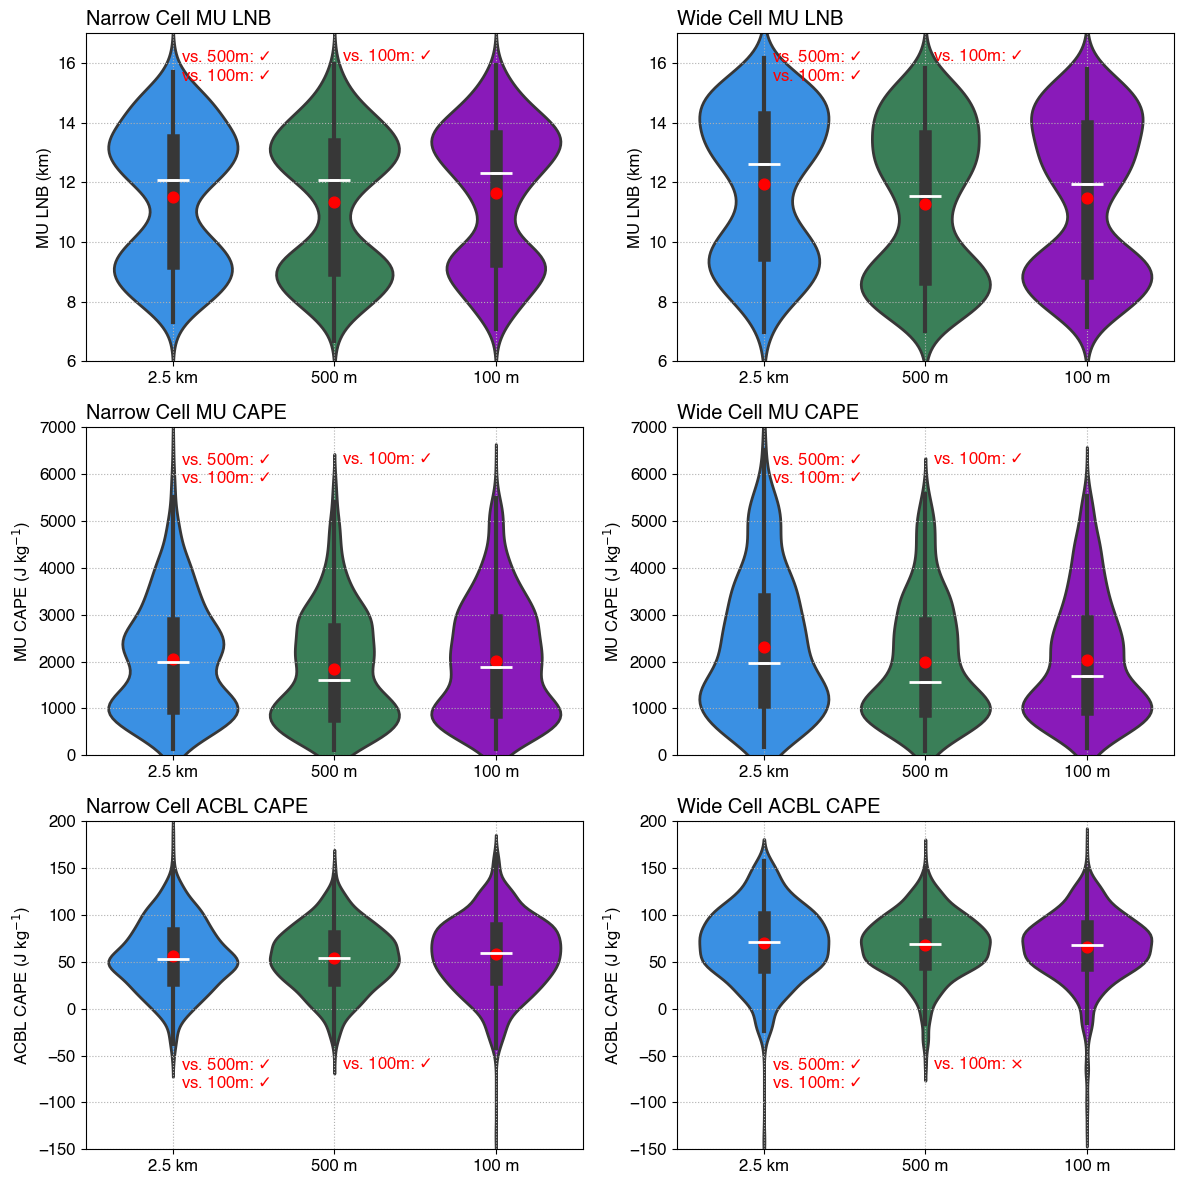

In [152]:
preCI_t = -3  # preCI time to get a single value

data_arr = [
    [[narrow_pELmu_d2.sel(times=preCI_t).values, narrow_pELmu_d3.sel(times=preCI_t).values, narrow_pELmu_d4.sel(times=preCI_t).values],
     [wide_pELmu_d2.sel(times=preCI_t).values, wide_pELmu_d3.sel(times=preCI_t), wide_pELmu_d4.sel(times=preCI_t).values]],
    [[narrow_pCAPEmu_d2.sel(times=preCI_t).values, narrow_pCAPEmu_d3.sel(times=preCI_t).values, narrow_pCAPEmu_d4.sel(times=preCI_t).values],
     [wide_pCAPEmu_d2.sel(times=preCI_t).values, wide_pCAPEmu_d3.sel(times=preCI_t).values, wide_pCAPEmu_d4.sel(times=preCI_t).values]],
    [[narrow_pCAPEacbl_d2.sel(times=preCI_t).values, narrow_pCAPEacbl_d3.sel(times=preCI_t).values, narrow_pCAPEacbl_d4.sel(times=preCI_t).values],
     [wide_pCAPEacbl_d2.sel(times=preCI_t).values, wide_pCAPEacbl_d3.sel(times=preCI_t).values, wide_pCAPEacbl_d4.sel(times=preCI_t).values]],
    # [[narrow_pCINmu_d2.sel(times=preCI_t).values, narrow_pCINmu_d3.sel(times=preCI_t).values, narrow_pCINmu_d4.sel(times=preCI_t).values],
    #  [wide_pCINmu_d2.sel(times=preCI_t).values, wide_pCINmu_d3.sel(times=preCI_t).values, wide_pCINmu_d4.sel(times=preCI_t).values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_pELmu23+'\n'+'vs. 100m: '+narrow_sig_pELmu23, 'd3':'vs. 100m: '+narrow_sig_pELmu34},
     {'d2':'vs. 500m: '+wide_sig_pELmu23+'\n'+'vs. 100m: '+wide_sig_pELmu23, 'd3':'vs. 100m: '+wide_sig_pELmu34},],
    [{'d2':'vs. 500m: '+narrow_sig_pCAPEmu23+'\n'+'vs. 100m: '+narrow_sig_pCAPEmu23, 'd3':'vs. 100m: '+narrow_sig_pCAPEmu34},
     {'d2':'vs. 500m: '+wide_sig_pCAPEmu23+'\n'+'vs. 100m: '+wide_sig_pCAPEmu23, 'd3':'vs. 100m: '+wide_sig_pCAPEmu34},],
    [{'d2':'vs. 500m: '+narrow_sig_pCAPEacbl23+'\n'+'vs. 100m: '+narrow_sig_pCAPEacbl23, 'd3':'vs. 100m: '+narrow_sig_pCAPEacbl34},
     {'d2':'vs. 500m: '+wide_sig_pCAPEacbl23+'\n'+'vs. 100m: '+wide_sig_pCAPEacbl23, 'd3':'vs. 100m: '+wide_sig_pCAPEacbl34},],
]
ypos_sig = [[16.5]*2, [6500]*2, [-50]*2]
titles = [
    ['Narrow Cell MU LNB','Wide Cell MU LNB'], 
    ['Narrow Cell MU CAPE','Wide Cell MU CAPE'], 
    ['Narrow Cell ACBL CAPE', 'Wide Cell ACBL CAPE'],
    # ['Narrow Cell MU CIN', 'Wide Cell MU CIN'],
]
ylabels = [['MU LNB (km)']*2, ['MU CAPE (J kg$^{-1}$)']*2, ['ACBL CAPE (J kg$^{-1}$)']*2]
ylims = [[(6,17)]*2, [(0,7000)]*2, [(-150,200)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 12
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_pEL_pCAPE_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [156]:
# LCL temperature
narrow_sig_LCLt23 = kstest_data(narrow_LCLt_d2.values[~np.isnan(narrow_LCLt_d2)], 
                                     narrow_LCLt_d3.values[~np.isnan(narrow_LCLt_d3)], 'Narrow Cell LCLt D2 vs. D3', alpha=alpha)
narrow_sig_LCLt24 = kstest_data(narrow_LCLt_d2.values[~np.isnan(narrow_LCLt_d2)], 
                                     narrow_LCLt_d4.values[~np.isnan(narrow_LCLt_d4)], 'Narrow Cell LCLt D2 vs. D4', alpha=alpha)
narrow_sig_LCLt34 = kstest_data(narrow_LCLt_d3.values[~np.isnan(narrow_LCLt_d3)], 
                                     narrow_LCLt_d4.values[~np.isnan(narrow_LCLt_d4)], 'Narrow Cell LCLt D3 vs. D4', alpha=alpha)
# LCL height
narrow_sig_LCLz23 = kstest_data(narrow_LCLz_d2.values[~np.isnan(narrow_LCLz_d2)], 
                                     narrow_LCLz_d3.values[~np.isnan(narrow_LCLz_d3)], 'Narrow Cell LCLz D2 vs. D3', alpha=alpha)
narrow_sig_LCLz24 = kstest_data(narrow_LCLz_d2.values[~np.isnan(narrow_LCLz_d2)], 
                                     narrow_LCLz_d4.values[~np.isnan(narrow_LCLz_d4)], 'Narrow Cell LCLz D2 vs. D4', alpha=alpha)
narrow_sig_LCLz34 = kstest_data(narrow_LCLz_d3.values[~np.isnan(narrow_LCLz_d3)], 
                                     narrow_LCLz_d4.values[~np.isnan(narrow_LCLz_d4)], 'Narrow Cell LCLz D3 vs. D4', alpha=alpha)
# LFC height
narrow_sig_pLFCz23 = kstest_data(narrow_pLFCz_d2.values[~np.isnan(narrow_pLFCz_d2)], 
                                     narrow_pLFCz_d3.values[~np.isnan(narrow_pLFCz_d3)], 'Narrow Cell pLFCz D2 vs. D3', alpha=alpha)
narrow_sig_pLFCz24 = kstest_data(narrow_pLFCz_d2.values[~np.isnan(narrow_pLFCz_d2)], 
                                     narrow_pLFCz_d4.values[~np.isnan(narrow_pLFCz_d4)], 'Narrow Cell pLFCz D2 vs. D4', alpha=alpha)
narrow_sig_pLFCz34 = kstest_data(narrow_pLFCz_d3.values[~np.isnan(narrow_pLFCz_d3)], 
                                     narrow_pLFCz_d4.values[~np.isnan(narrow_pLFCz_d4)], 'Narrow Cell pLFCz D3 vs. D4', alpha=alpha)

# LCL temperature
wide_sig_LCLt23 = kstest_data(wide_LCLt_d2.values[~np.isnan(wide_LCLt_d2)], 
                                     wide_LCLt_d3.values[~np.isnan(wide_LCLt_d3)], 'Wide Cell LCLt D2 vs. D3', alpha=alpha)
wide_sig_LCLt24 = kstest_data(wide_LCLt_d2.values[~np.isnan(wide_LCLt_d2)], 
                                     wide_LCLt_d4.values[~np.isnan(wide_LCLt_d4)], 'Wide Cell LCLt D2 vs. D4', alpha=alpha)
wide_sig_LCLt34 = kstest_data(wide_LCLt_d3.values[~np.isnan(wide_LCLt_d3)], 
                                     wide_LCLt_d4.values[~np.isnan(wide_LCLt_d4)], 'Wide Cell LCLt D3 vs. D4', alpha=alpha)
# LCL height
wide_sig_LCLz23 = kstest_data(wide_LCLz_d2.values[~np.isnan(wide_LCLz_d2)], 
                                     wide_LCLz_d3.values[~np.isnan(wide_LCLz_d3)], 'Wide Cell LCLz D2 vs. D3', alpha=alpha)
wide_sig_LCLz24 = kstest_data(wide_LCLz_d2.values[~np.isnan(wide_LCLz_d2)], 
                                     wide_LCLz_d4.values[~np.isnan(wide_LCLz_d4)], 'Wide Cell LCLz D2 vs. D4', alpha=alpha)
wide_sig_LCLz34 = kstest_data(wide_LCLz_d3.values[~np.isnan(wide_LCLz_d3)], 
                                     wide_LCLz_d4.values[~np.isnan(wide_LCLz_d4)], 'Wide Cell LCLz D3 vs. D4', alpha=alpha)
# LFC height
wide_sig_pLFCz23 = kstest_data(wide_pLFCz_d2.values[~np.isnan(wide_pLFCz_d2)], 
                                     wide_pLFCz_d3.values[~np.isnan(wide_pLFCz_d3)], 'Wide Cell pLFCz D2 vs. D3', alpha=alpha)
wide_sig_pLFCz24 = kstest_data(wide_pLFCz_d2.values[~np.isnan(wide_pLFCz_d2)], 
                                     wide_pLFCz_d4.values[~np.isnan(wide_pLFCz_d4)], 'Wide Cell pLFCz D2 vs. D4', alpha=alpha)
wide_sig_pLFCz34 = kstest_data(wide_pLFCz_d3.values[~np.isnan(wide_pLFCz_d3)], 
                                     wide_pLFCz_d4.values[~np.isnan(wide_pLFCz_d4)], 'Wide Cell pLFCz D3 vs. D4', alpha=alpha)

Narrow Cell LCLt D2 vs. D3: Different distributions
Statistics=0.117, p=0.000
Narrow Cell LCLt D2 vs. D4: Different distributions
Statistics=0.080, p=0.000
Narrow Cell LCLt D3 vs. D4: Different distributions
Statistics=0.061, p=0.000
Narrow Cell LCLz D2 vs. D3: Different distributions
Statistics=0.162, p=0.000
Narrow Cell LCLz D2 vs. D4: Different distributions
Statistics=0.139, p=0.000
Narrow Cell LCLz D3 vs. D4: Different distributions
Statistics=0.025, p=0.002
Narrow Cell pLFCz D2 vs. D3: Different distributions
Statistics=0.122, p=0.000
Narrow Cell pLFCz D2 vs. D4: Different distributions
Statistics=0.115, p=0.000
Narrow Cell pLFCz D3 vs. D4: Different distributions
Statistics=0.027, p=0.001
Wide Cell LCLt D2 vs. D3: Different distributions
Statistics=0.131, p=0.000
Wide Cell LCLt D2 vs. D4: Different distributions
Statistics=0.115, p=0.000
Wide Cell LCLt D3 vs. D4: Different distributions
Statistics=0.028, p=0.000
Wide Cell LCLz D2 vs. D3: Same distributions
Statistics=0.022, p=0.

/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


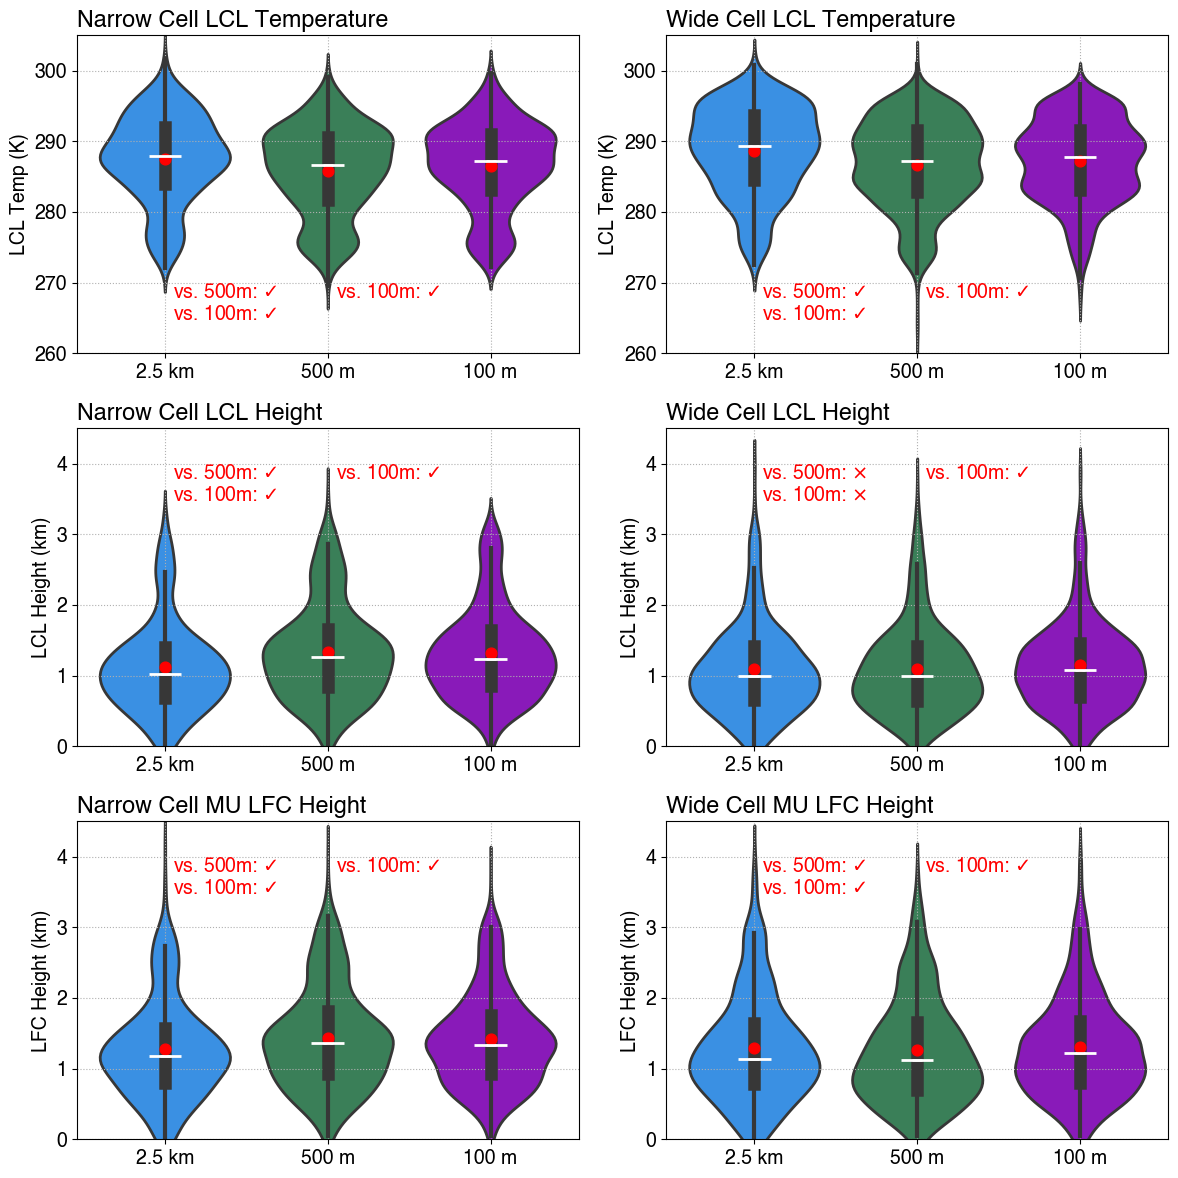

In [158]:
data_arr = [
    [[narrow_LCLt_d2.sel(times=preCI_t).values, narrow_LCLt_d3.sel(times=preCI_t).values, narrow_LCLt_d4.sel(times=preCI_t).values],
     [wide_LCLt_d2.sel(times=preCI_t).values, wide_LCLt_d3.sel(times=preCI_t).values, wide_LCLt_d4.sel(times=preCI_t).values]],
    [[narrow_LCLz_d2.sel(times=preCI_t).values, narrow_LCLz_d3.sel(times=preCI_t).values, narrow_LCLz_d4.sel(times=preCI_t).values],
     [wide_LCLz_d2.sel(times=preCI_t).values, wide_LCLz_d3.sel(times=preCI_t).values, wide_LCLz_d4.sel(times=preCI_t).values]],
    [[narrow_pLFCz_d2.sel(times=preCI_t).values, narrow_pLFCz_d3.sel(times=preCI_t).values, narrow_pLFCz_d4.sel(times=preCI_t).values],
     [wide_pLFCz_d2.sel(times=preCI_t).values, wide_pLFCz_d3.sel(times=preCI_t).values, wide_pLFCz_d4.sel(times=preCI_t).values]],
]
titles = [
    ['Narrow Cell LCL Temperature','Wide Cell LCL Temperature'], 
    ['Narrow Cell LCL Height','Wide Cell LCL Height'], 
    ['Narrow Cell MU LFC Height', 'Wide Cell MU LFC Height'],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_LCLt23+'\n'+'vs. 100m: '+narrow_sig_LCLt23, 'd3':'vs. 100m: '+narrow_sig_LCLt34},
     {'d2':'vs. 500m: '+wide_sig_LCLt23+'\n'+'vs. 100m: '+wide_sig_LCLt23, 'd3':'vs. 100m: '+wide_sig_LCLt34},],
    [{'d2':'vs. 500m: '+narrow_sig_LCLz23+'\n'+'vs. 100m: '+narrow_sig_LCLz23, 'd3':'vs. 100m: '+narrow_sig_LCLz34},
     {'d2':'vs. 500m: '+wide_sig_LCLz23+'\n'+'vs. 100m: '+wide_sig_LCLz23, 'd3':'vs. 100m: '+wide_sig_LCLz34},],
    [{'d2':'vs. 500m: '+narrow_sig_pLFCz23+'\n'+'vs. 100m: '+narrow_sig_pLFCz23, 'd3':'vs. 100m: '+narrow_sig_pLFCz34},
     {'d2':'vs. 500m: '+wide_sig_pLFCz23+'\n'+'vs. 100m: '+wide_sig_pLFCz23, 'd3':'vs. 100m: '+wide_sig_pLFCz34},],
]
ypos_sig = [[270]*2, [4]*2, [4]*2]
ylabels = [['LCL Temp (K)']*2, ['LCL Height (km)']*2, ['LFC Height (km)']*2, ]
ylims = [[(260,305)]*2, [(0,4.5)]*2, [(0,4.5)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_LCL_pLFC_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)
# fig = plot_mxn_violin(nrow, ncol, data_arr, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [159]:
# ACBL RH
narrow_sig_RHacbl23 = kstest_data(narrow_RHacbl_d2.values[~np.isnan(narrow_RHacbl_d2)], 
                                     narrow_RHacbl_d3.values[~np.isnan(narrow_RHacbl_d3)], 'Narrow Cell RHacbl D2 vs. D3', alpha=alpha)
narrow_sig_RHacbl24 = kstest_data(narrow_RHacbl_d2.values[~np.isnan(narrow_RHacbl_d2)], 
                                     narrow_RHacbl_d4.values[~np.isnan(narrow_RHacbl_d4)], 'Narrow Cell RHacbl D2 vs. D4', alpha=alpha)
narrow_sig_RHacbl34 = kstest_data(narrow_RHacbl_d3.values[~np.isnan(narrow_RHacbl_d3)], 
                                     narrow_RHacbl_d4.values[~np.isnan(narrow_RHacbl_d4)], 'Narrow Cell RHacbl D3 vs. D4', alpha=alpha)
# LFC to LFC+1500m RH
narrow_sig_RHlfc150023 = kstest_data(narrow_RHlfc1500_d2.values[~np.isnan(narrow_RHlfc1500_d2)], 
                                     narrow_RHlfc1500_d3.values[~np.isnan(narrow_RHlfc1500_d3)], 'Narrow Cell RHlfc1500 D2 vs. D3', alpha=alpha)
narrow_sig_RHlfc150024 = kstest_data(narrow_RHlfc1500_d2.values[~np.isnan(narrow_RHlfc1500_d2)], 
                                     narrow_RHlfc1500_d4.values[~np.isnan(narrow_RHlfc1500_d4)], 'Narrow Cell RHlfc1500 D2 vs. D4', alpha=alpha)
narrow_sig_RHlfc150034 = kstest_data(narrow_RHlfc1500_d3.values[~np.isnan(narrow_RHlfc1500_d3)], 
                                     narrow_RHlfc1500_d4.values[~np.isnan(narrow_RHlfc1500_d4)], 'Narrow Cell RHlfc1500 D3 vs. D4', alpha=alpha)
# RH
narrow_sig_RH600mb23 = kstest_data(narrow_RH600mb_d2.values[~np.isnan(narrow_RH600mb_d2)], 
                                     narrow_RH600mb_d3.values[~np.isnan(narrow_RH600mb_d3)], 'Narrow Cell RH600mb D2 vs. D3', alpha=alpha)
narrow_sig_RH600mb24 = kstest_data(narrow_RH600mb_d2.values[~np.isnan(narrow_RH600mb_d2)], 
                                     narrow_RH600mb_d4.values[~np.isnan(narrow_RH600mb_d4)], 'Narrow Cell RH600mb D2 vs. D4', alpha=alpha)
narrow_sig_RH600mb34 = kstest_data(narrow_RH600mb_d3.values[~np.isnan(narrow_RH600mb_d3)], 
                                     narrow_RH600mb_d4.values[~np.isnan(narrow_RH600mb_d4)], 'Narrow Cell RH600mb D3 vs. D4', alpha=alpha)

narrow_sig_RH500mb23 = kstest_data(narrow_RH500mb_d2.values[~np.isnan(narrow_RH500mb_d2)], 
                                     narrow_RH500mb_d3.values[~np.isnan(narrow_RH500mb_d3)], 'Narrow Cell RH500mb D2 vs. D3', alpha=alpha)
narrow_sig_RH500mb24 = kstest_data(narrow_RH500mb_d2.values[~np.isnan(narrow_RH500mb_d2)], 
                                     narrow_RH500mb_d4.values[~np.isnan(narrow_RH500mb_d4)], 'Narrow Cell RH500mb D2 vs. D4', alpha=alpha)
narrow_sig_RH500mb34 = kstest_data(narrow_RH500mb_d3.values[~np.isnan(narrow_RH500mb_d3)], 
                                     narrow_RH500mb_d4.values[~np.isnan(narrow_RH500mb_d4)], 'Narrow Cell RH500mb D3 vs. D4', alpha=alpha)
# PW
narrow_sig_PW23 = kstest_data(narrow_PW_d2.values[~np.isnan(narrow_PW_d2)], 
                                     narrow_PW_d3.values[~np.isnan(narrow_PW_d3)], 'narrow Cell PW D2 vs. D3', alpha=alpha)
narrow_sig_PW24 = kstest_data(narrow_PW_d2.values[~np.isnan(narrow_PW_d2)], 
                                     narrow_PW_d4.values[~np.isnan(narrow_PW_d4)], 'narrow Cell PW D2 vs. D4', alpha=alpha)
narrow_sig_PW34 = kstest_data(narrow_PW_d3.values[~np.isnan(narrow_PW_d3)], 
                                     narrow_PW_d4.values[~np.isnan(narrow_PW_d4)], 'narrow Cell PW D3 vs. D4', alpha=alpha)

# MU LNB
wide_sig_RHacbl23 = kstest_data(wide_RHacbl_d2.values[~np.isnan(wide_RHacbl_d2)], 
                                     wide_RHacbl_d3.values[~np.isnan(wide_RHacbl_d3)], 'Wide Cell RHacbl D2 vs. D3', alpha=alpha)
wide_sig_RHacbl24 = kstest_data(wide_RHacbl_d2.values[~np.isnan(wide_RHacbl_d2)], 
                                     wide_RHacbl_d4.values[~np.isnan(wide_RHacbl_d4)], 'Wide Cell RHacbl D2 vs. D4', alpha=alpha)
wide_sig_RHacbl34 = kstest_data(wide_RHacbl_d3.values[~np.isnan(wide_RHacbl_d3)], 
                                     wide_RHacbl_d4.values[~np.isnan(wide_RHacbl_d4)], 'Wide Cell RHacbl D3 vs. D4', alpha=alpha)
# MU CAPE
wide_sig_RHlfc150023 = kstest_data(wide_RHlfc1500_d2.values[~np.isnan(wide_RHlfc1500_d2)], 
                                     wide_RHlfc1500_d3.values[~np.isnan(wide_RHlfc1500_d3)], 'Wide Cell RHlfc1500 D2 vs. D3', alpha=alpha)
wide_sig_RHlfc150024 = kstest_data(wide_RHlfc1500_d2.values[~np.isnan(wide_RHlfc1500_d2)], 
                                     wide_RHlfc1500_d4.values[~np.isnan(wide_RHlfc1500_d4)], 'Wide Cell RHlfc1500 D2 vs. D4', alpha=alpha)
wide_sig_RHlfc150034 = kstest_data(wide_RHlfc1500_d3.values[~np.isnan(wide_RHlfc1500_d3)], 
                                     wide_RHlfc1500_d4.values[~np.isnan(wide_RHlfc1500_d4)], 'Wide Cell RHlfc1500 D3 vs. D4', alpha=alpha)
# ACBL CAPE
wide_sig_RH600mb23 = kstest_data(wide_RH600mb_d2.values[~np.isnan(wide_RH600mb_d2)], 
                                     wide_RH600mb_d3.values[~np.isnan(wide_RH600mb_d3)], 'Wide Cell RH600mb D2 vs. D3', alpha=alpha)
wide_sig_RH600mb24 = kstest_data(wide_RH600mb_d2.values[~np.isnan(wide_RH600mb_d2)], 
                                     wide_RH600mb_d4.values[~np.isnan(wide_RH600mb_d4)], 'Wide Cell RH600mb D2 vs. D4', alpha=alpha)
wide_sig_RH600mb34 = kstest_data(wide_RH600mb_d3.values[~np.isnan(wide_RH600mb_d3)], 
                                     wide_RH600mb_d4.values[~np.isnan(wide_RH600mb_d4)], 'Wide Cell RH600mb D3 vs. D4', alpha=alpha)

wide_sig_RH500mb23 = kstest_data(wide_RH500mb_d2.values[~np.isnan(wide_RH500mb_d2)], 
                                     wide_RH500mb_d3.values[~np.isnan(wide_RH500mb_d3)], 'wide Cell RH500mb D2 vs. D3', alpha=alpha)
wide_sig_RH500mb24 = kstest_data(wide_RH500mb_d2.values[~np.isnan(wide_RH500mb_d2)], 
                                     wide_RH500mb_d4.values[~np.isnan(wide_RH500mb_d4)], 'wide Cell RH500mb D2 vs. D4', alpha=alpha)
wide_sig_RH500mb34 = kstest_data(wide_RH500mb_d3.values[~np.isnan(wide_RH500mb_d3)], 
                                     wide_RH500mb_d4.values[~np.isnan(wide_RH500mb_d4)], 'wide Cell RH500mb D3 vs. D4', alpha=alpha)
# PW
wide_sig_PW23 = kstest_data(wide_PW_d2.values[~np.isnan(wide_PW_d2)], 
                                     wide_PW_d3.values[~np.isnan(wide_PW_d3)], 'wide Cell PW D2 vs. D3', alpha=alpha)
wide_sig_PW24 = kstest_data(wide_PW_d2.values[~np.isnan(wide_PW_d2)], 
                                     wide_PW_d4.values[~np.isnan(wide_PW_d4)], 'wide Cell PW D2 vs. D4', alpha=alpha)
wide_sig_PW34 = kstest_data(wide_PW_d3.values[~np.isnan(wide_PW_d3)], 
                                     wide_PW_d4.values[~np.isnan(wide_PW_d4)], 'wide Cell PW D3 vs. D4', alpha=alpha)

Narrow Cell RHacbl D2 vs. D3: Different distributions
Statistics=0.091, p=0.000
Narrow Cell RHacbl D2 vs. D4: Different distributions
Statistics=0.055, p=0.000
Narrow Cell RHacbl D3 vs. D4: Different distributions
Statistics=0.077, p=0.000
Narrow Cell RHlfc1500 D2 vs. D3: Different distributions
Statistics=0.064, p=0.000
Narrow Cell RHlfc1500 D2 vs. D4: Different distributions
Statistics=0.066, p=0.000
Narrow Cell RHlfc1500 D3 vs. D4: Different distributions
Statistics=0.023, p=0.006
Narrow Cell RH600mb D2 vs. D3: Different distributions
Statistics=0.103, p=0.000
Narrow Cell RH600mb D2 vs. D4: Different distributions
Statistics=0.132, p=0.000
Narrow Cell RH600mb D3 vs. D4: Different distributions
Statistics=0.051, p=0.000
Narrow Cell RH500mb D2 vs. D3: Different distributions
Statistics=0.121, p=0.000
Narrow Cell RH500mb D2 vs. D4: Different distributions
Statistics=0.131, p=0.000
Narrow Cell RH500mb D3 vs. D4: Same distributions
Statistics=0.018, p=0.054
narrow Cell PW D2 vs. D3: Diff

/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xtickl

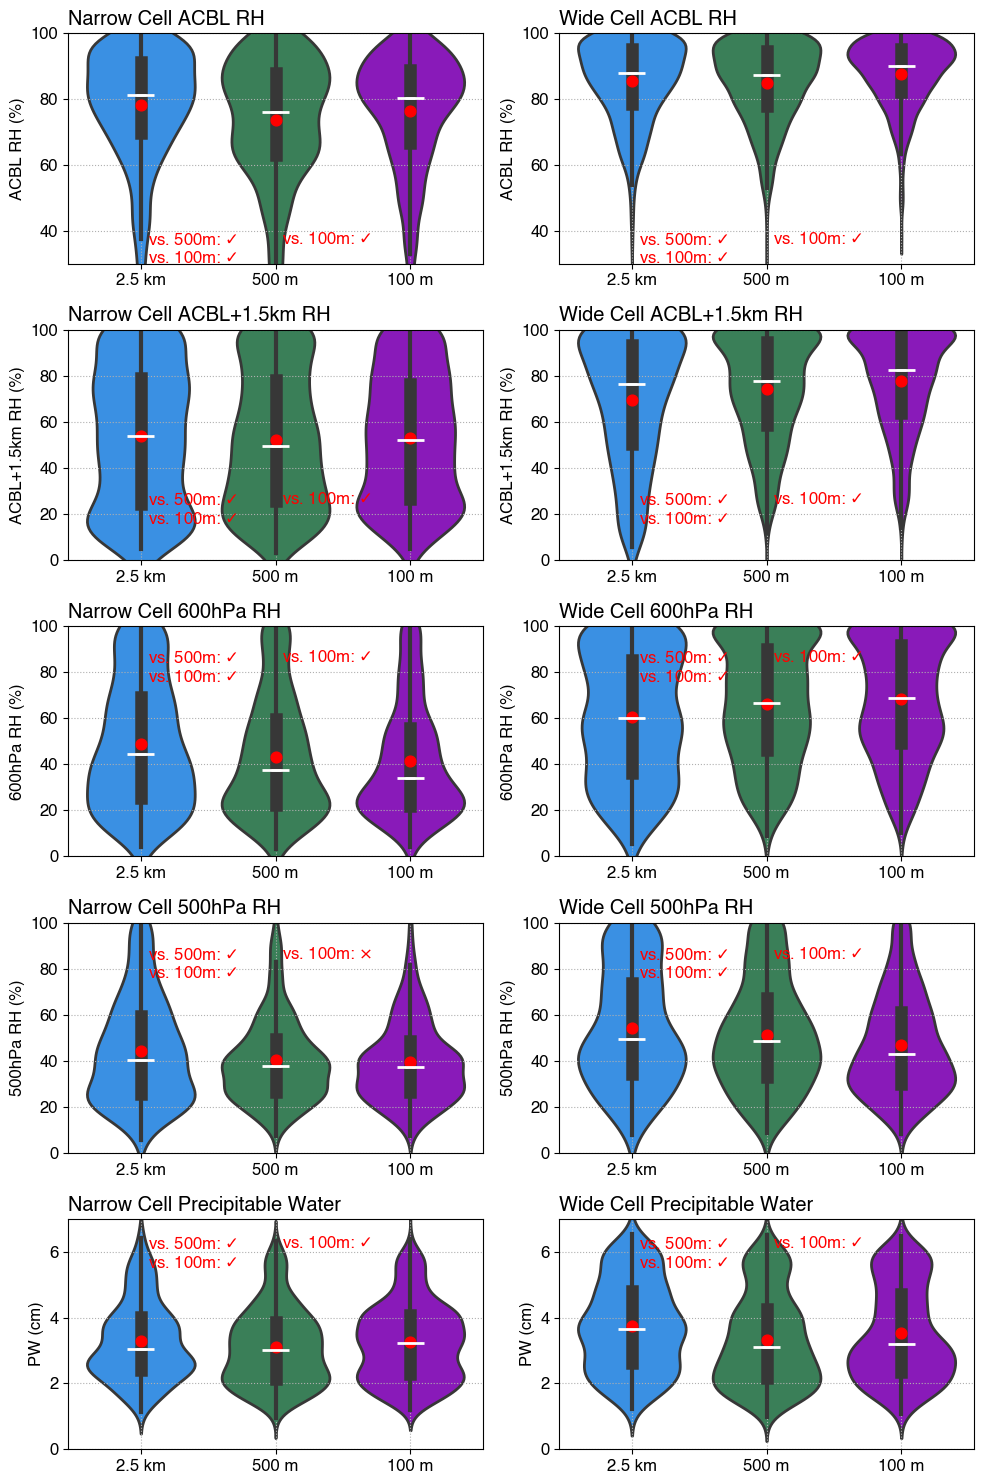

In [163]:
data_arr = [
    [[narrow_RHacbl_d2.sel(times=preCI_t).values, narrow_RHacbl_d3.sel(times=preCI_t).values, narrow_RHacbl_d4.sel(times=preCI_t).values],
     [wide_RHacbl_d2.sel(times=preCI_t).values, wide_RHacbl_d3.sel(times=preCI_t).values, wide_RHacbl_d4.sel(times=preCI_t).values]],
    [[narrow_RHlfc1500_d2.sel(times=preCI_t).values, narrow_RHlfc1500_d3.sel(times=preCI_t).values, narrow_RHlfc1500_d4.sel(times=preCI_t).values],
     [wide_RHlfc1500_d2.sel(times=preCI_t).values, wide_RHlfc1500_d3.sel(times=preCI_t).values, wide_RHlfc1500_d4.sel(times=preCI_t).values]],
    [[narrow_RH600mb_d2.sel(times=preCI_t).values, narrow_RH600mb_d3.sel(times=preCI_t).values, narrow_RH600mb_d4.sel(times=preCI_t).values],
     [wide_RH600mb_d2.sel(times=preCI_t).values, wide_RH600mb_d3.sel(times=preCI_t).values, wide_RH600mb_d4.sel(times=preCI_t).values]],
    [[narrow_RH500mb_d2.sel(times=preCI_t).values, narrow_RH500mb_d3.sel(times=preCI_t).values, narrow_RH500mb_d4.sel(times=preCI_t).values],
     [wide_RH500mb_d2.sel(times=preCI_t).values, wide_RH500mb_d3.sel(times=preCI_t).values, wide_RH500mb_d4.sel(times=preCI_t).values]],
    [[narrow_PW_d2.sel(times=preCI_t).values, narrow_PW_d3.sel(times=preCI_t).values, narrow_PW_d4.sel(times=preCI_t).values],
     [wide_PW_d2.sel(times=preCI_t).values, wide_PW_d3.sel(times=preCI_t).values, wide_PW_d4.sel(times=preCI_t).values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_RHacbl23+'\n'+'vs. 100m: '+narrow_sig_RHacbl23, 'd3':'vs. 100m: '+narrow_sig_RHacbl34},
     {'d2':'vs. 500m: '+wide_sig_RHacbl23+'\n'+'vs. 100m: '+wide_sig_RHacbl23, 'd3':'vs. 100m: '+wide_sig_RHacbl34},],
    [{'d2':'vs. 500m: '+narrow_sig_RHlfc150023+'\n'+'vs. 100m: '+narrow_sig_RHlfc150023, 'd3':'vs. 100m: '+narrow_sig_RHlfc150034},
     {'d2':'vs. 500m: '+wide_sig_RHlfc150023+'\n'+'vs. 100m: '+wide_sig_RHlfc150023, 'd3':'vs. 100m: '+wide_sig_RHlfc150034},],
    [{'d2':'vs. 500m: '+narrow_sig_RH600mb23+'\n'+'vs. 100m: '+narrow_sig_RH600mb23, 'd3':'vs. 100m: '+narrow_sig_RH600mb34},
     {'d2':'vs. 500m: '+wide_sig_RH600mb23+'\n'+'vs. 100m: '+wide_sig_RH600mb23, 'd3':'vs. 100m: '+wide_sig_RH600mb34},],
    [{'d2':'vs. 500m: '+narrow_sig_RH500mb23+'\n'+'vs. 100m: '+narrow_sig_RH500mb23, 'd3':'vs. 100m: '+narrow_sig_RH500mb34},
     {'d2':'vs. 500m: '+wide_sig_RH500mb23+'\n'+'vs. 100m: '+wide_sig_RH500mb23, 'd3':'vs. 100m: '+wide_sig_RH500mb34},],
    [{'d2':'vs. 500m: '+narrow_sig_PW23+'\n'+'vs. 100m: '+narrow_sig_PW23, 'd3':'vs. 100m: '+narrow_sig_PW34},
     {'d2':'vs. 500m: '+wide_sig_PW23+'\n'+'vs. 100m: '+wide_sig_PW23, 'd3':'vs. 100m: '+wide_sig_PW34},],
]
ypos_sig = [[40]*2, [30]*2, [90]*2, [90]*2, [6.5]*2]
titles = [
    ['Narrow Cell ACBL RH','Wide Cell ACBL RH'], 
    ['Narrow Cell ACBL+1.5km RH','Wide Cell ACBL+1.5km RH'], 
    ['Narrow Cell 600hPa RH','Wide Cell 600hPa RH'], 
    ['Narrow Cell 500hPa RH', 'Wide Cell 500hPa RH'],
    ['Narrow Cell Precipitable Water', 'Wide Cell Precipitable Water'],
]
ylabels = [['ACBL RH (%)']*2, ['ACBL+1.5km RH (%)']*2, ['600hPa RH (%)']*2, ['500hPa RH (%)']*2, ['PW (cm)']*2]
ylims = [[(30,100)]*2, [(0,100)]*2, [(0,100)]*2, [(0,100)]*2, [(0,7)]*2]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 12
figsize = (10, 15)
figname = f'{figdir}Violin_NarrowWide_RH_PW_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [164]:
# LCL temperature
narrow_sig_BWSacbl23 = kstest_data(narrow_BWSacbl_d2.values[~np.isnan(narrow_BWSacbl_d2)], 
                                     narrow_BWSacbl_d3.values[~np.isnan(narrow_BWSacbl_d3)], 'Narrow Cell BWSacbl D2 vs. D3', alpha=alpha)
narrow_sig_BWSacbl24 = kstest_data(narrow_BWSacbl_d2.values[~np.isnan(narrow_BWSacbl_d2)], 
                                     narrow_BWSacbl_d4.values[~np.isnan(narrow_BWSacbl_d4)], 'Narrow Cell BWSacbl D2 vs. D4', alpha=alpha)
narrow_sig_BWSacbl34 = kstest_data(narrow_BWSacbl_d3.values[~np.isnan(narrow_BWSacbl_d3)], 
                                     narrow_BWSacbl_d4.values[~np.isnan(narrow_BWSacbl_d4)], 'Narrow Cell BWSacbl D3 vs. D4', alpha=alpha)
# LCL height
narrow_sig_BWS03km23 = kstest_data(narrow_BWS03km_d2.values[~np.isnan(narrow_BWS03km_d2)], 
                                     narrow_BWS03km_d3.values[~np.isnan(narrow_BWS03km_d3)], 'Narrow Cell BWS03km D2 vs. D3', alpha=alpha)
narrow_sig_BWS03km24 = kstest_data(narrow_BWS03km_d2.values[~np.isnan(narrow_BWS03km_d2)], 
                                     narrow_BWS03km_d4.values[~np.isnan(narrow_BWS03km_d4)], 'Narrow Cell BWS03km D2 vs. D4', alpha=alpha)
narrow_sig_BWS03km34 = kstest_data(narrow_BWS03km_d3.values[~np.isnan(narrow_BWS03km_d3)], 
                                     narrow_BWS03km_d4.values[~np.isnan(narrow_BWS03km_d4)], 'Narrow Cell BWS03km D3 vs. D4', alpha=alpha)
# LFC height
narrow_sig_BWS06km23 = kstest_data(narrow_BWS06km_d2.values[~np.isnan(narrow_BWS06km_d2)], 
                                     narrow_BWS06km_d3.values[~np.isnan(narrow_BWS06km_d3)], 'Narrow Cell BWS06km D2 vs. D3', alpha=alpha)
narrow_sig_BWS06km24 = kstest_data(narrow_BWS06km_d2.values[~np.isnan(narrow_BWS06km_d2)], 
                                     narrow_BWS06km_d4.values[~np.isnan(narrow_BWS06km_d4)], 'Narrow Cell BWS06km D2 vs. D4', alpha=alpha)
narrow_sig_BWS06km34 = kstest_data(narrow_BWS06km_d3.values[~np.isnan(narrow_BWS06km_d3)], 
                                     narrow_BWS06km_d4.values[~np.isnan(narrow_BWS06km_d4)], 'Narrow Cell BWS06km D3 vs. D4', alpha=alpha)

# LCL temperature
wide_sig_BWSacbl23 = kstest_data(wide_BWSacbl_d2.values[~np.isnan(wide_BWSacbl_d2)], 
                                     wide_BWSacbl_d3.values[~np.isnan(wide_BWSacbl_d3)], 'Wide Cell BWSacbl D2 vs. D3', alpha=alpha)
wide_sig_BWSacbl24 = kstest_data(wide_BWSacbl_d2.values[~np.isnan(wide_BWSacbl_d2)], 
                                     wide_BWSacbl_d4.values[~np.isnan(wide_BWSacbl_d4)], 'Wide Cell BWSacbl D2 vs. D4', alpha=alpha)
wide_sig_BWSacbl34 = kstest_data(wide_BWSacbl_d3.values[~np.isnan(wide_BWSacbl_d3)], 
                                     wide_BWSacbl_d4.values[~np.isnan(wide_BWSacbl_d4)], 'Wide Cell BWSacbl D3 vs. D4', alpha=alpha)
# LCL height
wide_sig_BWS03km23 = kstest_data(wide_BWS03km_d2.values[~np.isnan(wide_BWS03km_d2)], 
                                     wide_BWS03km_d3.values[~np.isnan(wide_BWS03km_d3)], 'Wide Cell BWS03km D2 vs. D3', alpha=alpha)
wide_sig_BWS03km24 = kstest_data(wide_BWS03km_d2.values[~np.isnan(wide_BWS03km_d2)], 
                                     wide_BWS03km_d4.values[~np.isnan(wide_BWS03km_d4)], 'Wide Cell BWS03km D2 vs. D4', alpha=alpha)
wide_sig_BWS03km34 = kstest_data(wide_BWS03km_d3.values[~np.isnan(wide_BWS03km_d3)], 
                                     wide_BWS03km_d4.values[~np.isnan(wide_BWS03km_d4)], 'Wide Cell BWS03km D3 vs. D4', alpha=alpha)
# LFC height
wide_sig_BWS06km23 = kstest_data(wide_BWS06km_d2.values[~np.isnan(wide_BWS06km_d2)], 
                                     wide_BWS06km_d3.values[~np.isnan(wide_BWS06km_d3)], 'Wide Cell BWS06km D2 vs. D3', alpha=alpha)
wide_sig_BWS06km24 = kstest_data(wide_BWS06km_d2.values[~np.isnan(wide_BWS06km_d2)], 
                                     wide_BWS06km_d4.values[~np.isnan(wide_BWS06km_d4)], 'Wide Cell BWS06km D2 vs. D4', alpha=alpha)
wide_sig_BWS06km34 = kstest_data(wide_BWS06km_d3.values[~np.isnan(wide_BWS06km_d3)], 
                                     wide_BWS06km_d4.values[~np.isnan(wide_BWS06km_d4)], 'Wide Cell BWS06km D3 vs. D4', alpha=alpha)

Narrow Cell BWSacbl D2 vs. D3: Same distributions
Statistics=0.018, p=0.103
Narrow Cell BWSacbl D2 vs. D4: Different distributions
Statistics=0.028, p=0.002
Narrow Cell BWSacbl D3 vs. D4: Different distributions
Statistics=0.024, p=0.003
Narrow Cell BWS03km D2 vs. D3: Same distributions
Statistics=0.022, p=0.027
Narrow Cell BWS03km D2 vs. D4: Different distributions
Statistics=0.039, p=0.000
Narrow Cell BWS03km D3 vs. D4: Different distributions
Statistics=0.031, p=0.000
Narrow Cell BWS06km D2 vs. D3: Different distributions
Statistics=0.030, p=0.001
Narrow Cell BWS06km D2 vs. D4: Different distributions
Statistics=0.053, p=0.000
Narrow Cell BWS06km D3 vs. D4: Different distributions
Statistics=0.062, p=0.000
Wide Cell BWSacbl D2 vs. D3: Same distributions
Statistics=0.016, p=0.300
Wide Cell BWSacbl D2 vs. D4: Different distributions
Statistics=0.040, p=0.000
Wide Cell BWSacbl D3 vs. D4: Different distributions
Statistics=0.036, p=0.000
Wide Cell BWS03km D2 vs. D3: Different distributi

/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_3842395/526822475.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


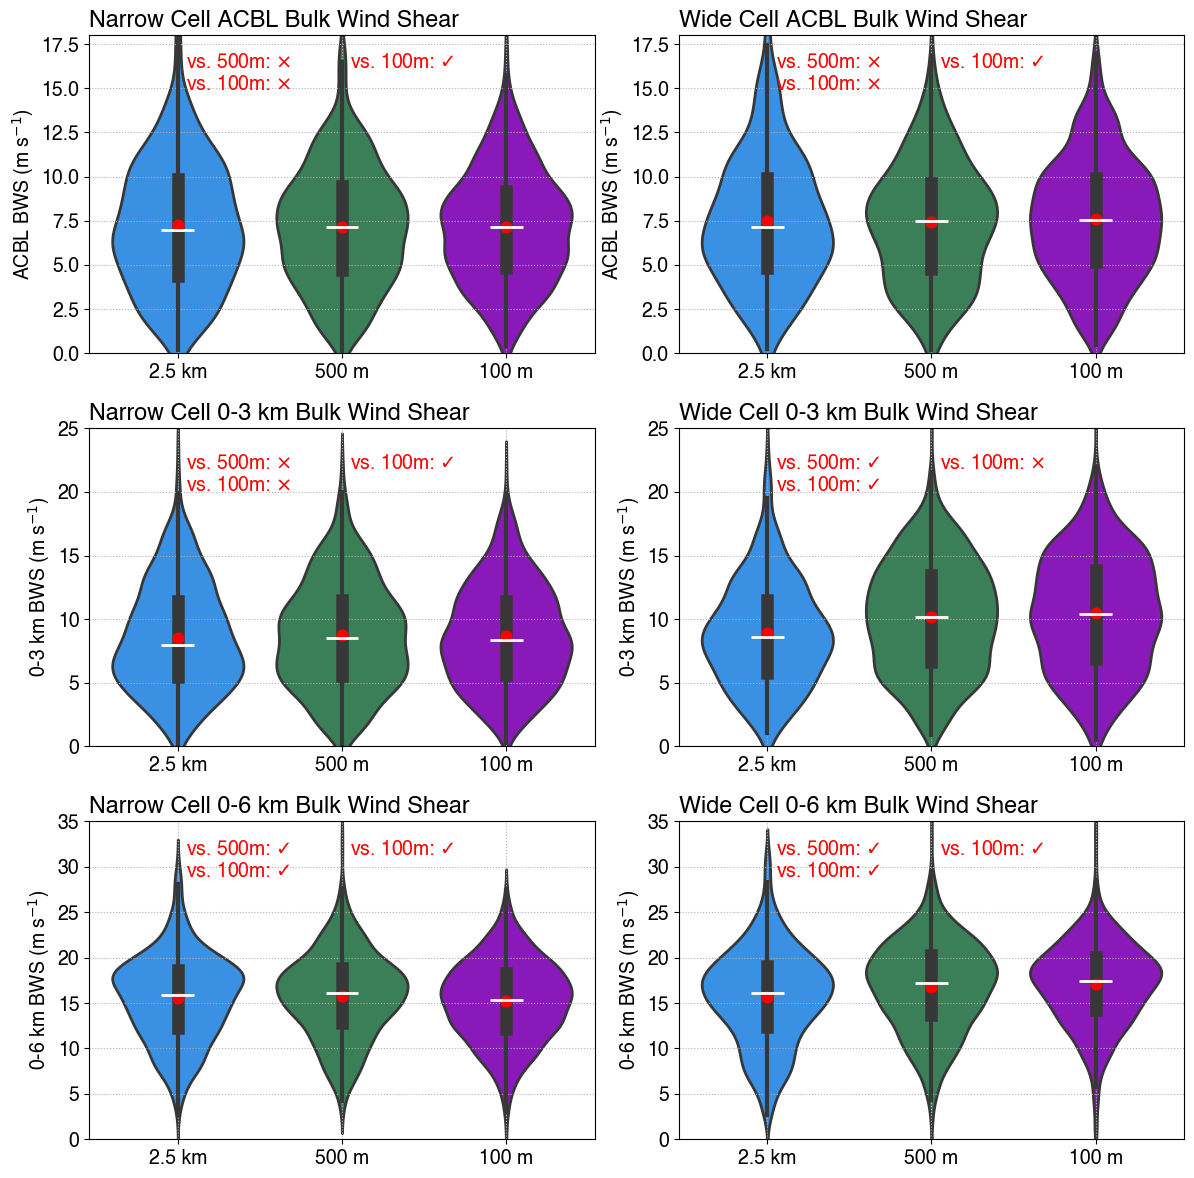

In [166]:
# bins_BWSacbl = np.arange(0, 18.1, 2)
# bins_BWS03km = np.arange(0, 25.1, 2.5)
# bins_BWS06km = np.arange(0, 35.1, 5)
# hist_bins = [
#     [bins_BWSacbl] * 2,
#     [bins_BWS03km] * 2,
#     [bins_BWS06km] * 2,
# ]
data_arr = [
    [[narrow_BWSacbl_d2.sel(times=preCI_t).values, narrow_BWSacbl_d3.sel(times=preCI_t).values, narrow_BWSacbl_d4.sel(times=preCI_t).values],
     [wide_BWSacbl_d2.sel(times=preCI_t).values, wide_BWSacbl_d3.sel(times=preCI_t).values, wide_BWSacbl_d4.sel(times=preCI_t).values]],
    [[narrow_BWS03km_d2.sel(times=preCI_t).values, narrow_BWS03km_d3.sel(times=preCI_t).values, narrow_BWS03km_d4.sel(times=preCI_t).values],
     [wide_BWS03km_d2.sel(times=preCI_t).values, wide_BWS03km_d3.sel(times=preCI_t).values, wide_BWS03km_d4.sel(times=preCI_t).values]],
    [[narrow_BWS06km_d2.sel(times=preCI_t).values, narrow_BWS06km_d3.sel(times=preCI_t).values, narrow_BWS06km_d4.sel(times=preCI_t).values],
     [wide_BWS06km_d2.sel(times=preCI_t).values, wide_BWS06km_d3.sel(times=preCI_t).values, wide_BWS06km_d4.sel(times=preCI_t).values]],
]
sigtest = [
    [{'d2':'vs. 500m: '+narrow_sig_BWSacbl23+'\n'+'vs. 100m: '+narrow_sig_BWSacbl23, 'd3':'vs. 100m: '+narrow_sig_BWSacbl34},
     {'d2':'vs. 500m: '+wide_sig_BWSacbl23+'\n'+'vs. 100m: '+wide_sig_BWSacbl23, 'd3':'vs. 100m: '+wide_sig_BWSacbl34},],
    [{'d2':'vs. 500m: '+narrow_sig_BWS03km23+'\n'+'vs. 100m: '+narrow_sig_BWS03km23, 'd3':'vs. 100m: '+narrow_sig_BWS03km34},
     {'d2':'vs. 500m: '+wide_sig_BWS03km23+'\n'+'vs. 100m: '+wide_sig_BWS03km23, 'd3':'vs. 100m: '+wide_sig_BWS03km34},],
    [{'d2':'vs. 500m: '+narrow_sig_BWS06km23+'\n'+'vs. 100m: '+narrow_sig_BWS06km23, 'd3':'vs. 100m: '+narrow_sig_BWS06km34},
     {'d2':'vs. 500m: '+wide_sig_BWS06km23+'\n'+'vs. 100m: '+wide_sig_BWS06km23, 'd3':'vs. 100m: '+wide_sig_BWS06km34},],
]
ypos_sig = [[17]*2, [23]*2, [33]*2]
titles = [
    ['Narrow Cell ACBL Bulk Wind Shear','Wide Cell ACBL Bulk Wind Shear'], 
    ['Narrow Cell 0-3 km Bulk Wind Shear','Wide Cell 0-3 km Bulk Wind Shear'], 
    ['Narrow Cell 0-6 km Bulk Wind Shear', 'Wide Cell 0-6 km Bulk Wind Shear'],
]
ylabels = [['ACBL BWS (m s$^{-1}$)']*2, ['0-3 km BWS (m s$^{-1}$)']*2, ['0-6 km BWS (m s$^{-1}$)']*2, ]
ylims = [[(0,18)]*2, [(0,25)]*2, [(0,35)]*2,]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}Violin_NarrowWide_BWS_d2_d3_d4.png'
fig = plot_mxn_violin(nrow, ncol, data_arr, sigtest=sigtest, ypos_sig=ypos_sig, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

## Function to plot nrow x ncol of histogram

In [43]:
def plot_mxn_hist(nrow, ncol, da, hist_bins, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    bar_labels = list(name_map.values())
    bar_colors = list(lcolors.values())
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            bar_data = da[row][col]
            bins = hist_bins[row][col]
            ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
            for src in range(len(bar_data)):
                ax.axvline(np.nanmedian(bar_data[src]), color=bar_colors[src], ls='--')
            ax.legend()
            # ax.set_xlim(xlims[row][col])
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':')
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

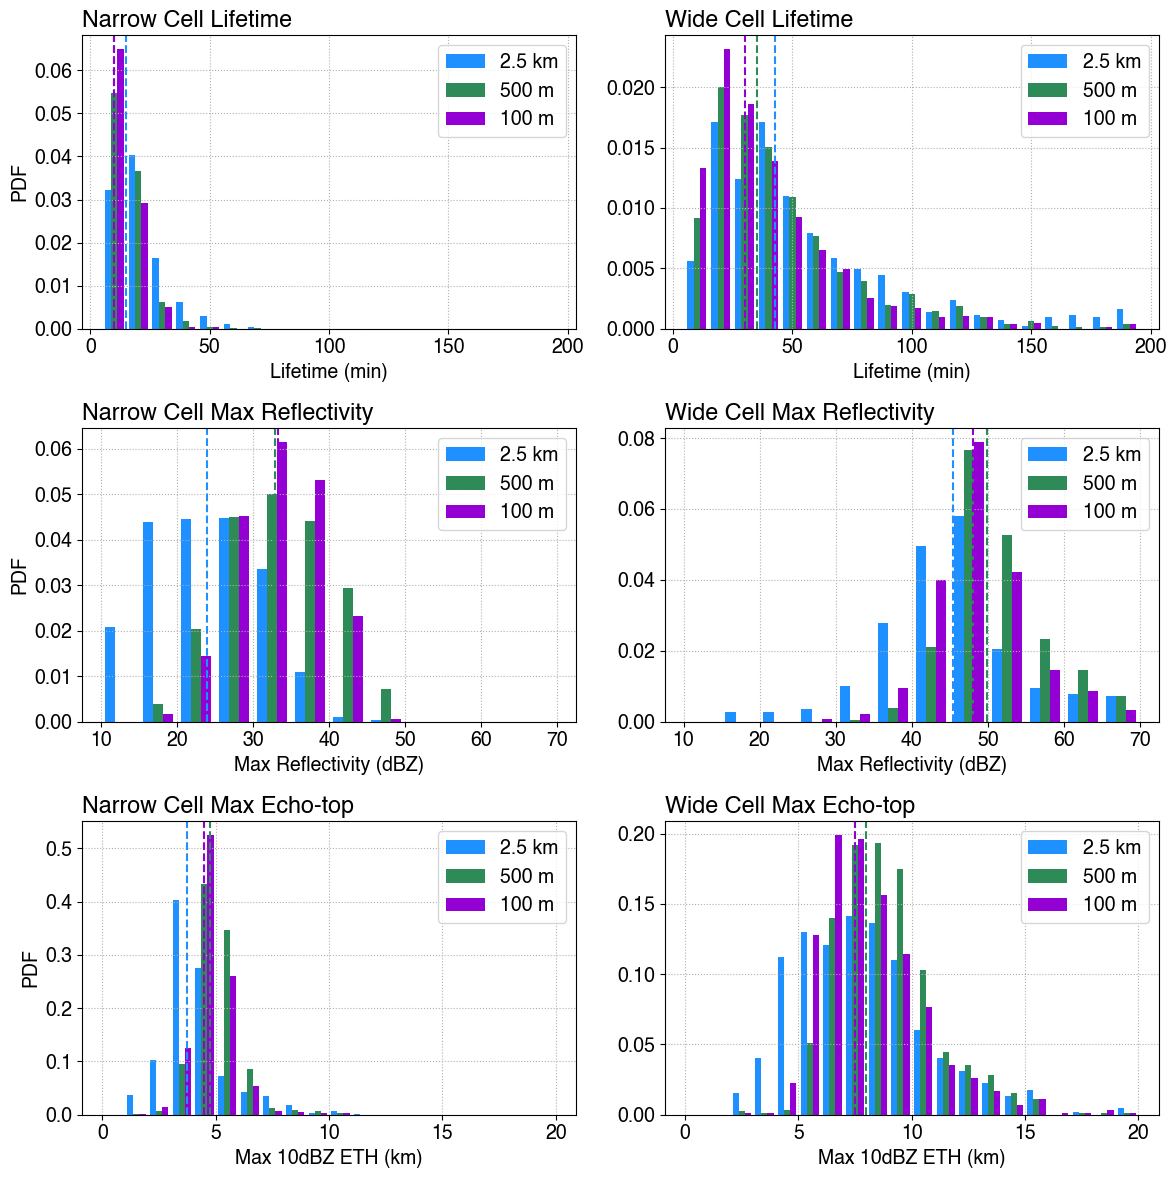

In [44]:
bins_lifetime = np.arange(5,200,10)
bins_maxdbz = np.arange(10, 71, 5)
bins_eth10dbz = np.arange(0, 21, 1)
hist_bins = [
    [bins_lifetime] * 2,
    [bins_maxdbz] * 2,
    [bins_eth10dbz] * 2,
]
data_arr = [
    [[narrow_track_lifetime_d2, narrow_track_lifetime_d3, narrow_track_lifetime_d4],[wide_track_lifetime_d2, wide_track_lifetime_d3, wide_track_lifetime_d4]],
    [[narrow_maxdbz_d2, narrow_maxdbz_d3, narrow_maxdbz_d4],[wide_maxdbz_d2, wide_maxdbz_d3, wide_maxdbz_d4]],
    [[narrow_maxETH10dbz_d2, narrow_maxETH10dbz_d3, narrow_maxETH10dbz_d4],[wide_maxETH10dbz_d2, wide_maxETH10dbz_d3, wide_maxETH10dbz_d4]],
]
titles = [['Narrow Cell Lifetime','Wide Cell Lifetime'], ['Narrow Cell Max Reflectivity','Wide Cell Max Reflectivity'], ['Narrow Cell Max Echo-top', 'Wide Cell Max Echo-top']]
xlabels = [['Lifetime (min)']*2, ['Max Reflectivity (dBZ)']*2, ['Max 10dBZ ETH (km)']*2, ]
ylabels = [['PDF',''], ['PDF',''], ['PDF',''],]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}PDF_NarrowWide_Lifetime_maxRefl_maxETH10dBZ_d2_d3_d4.png'
fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

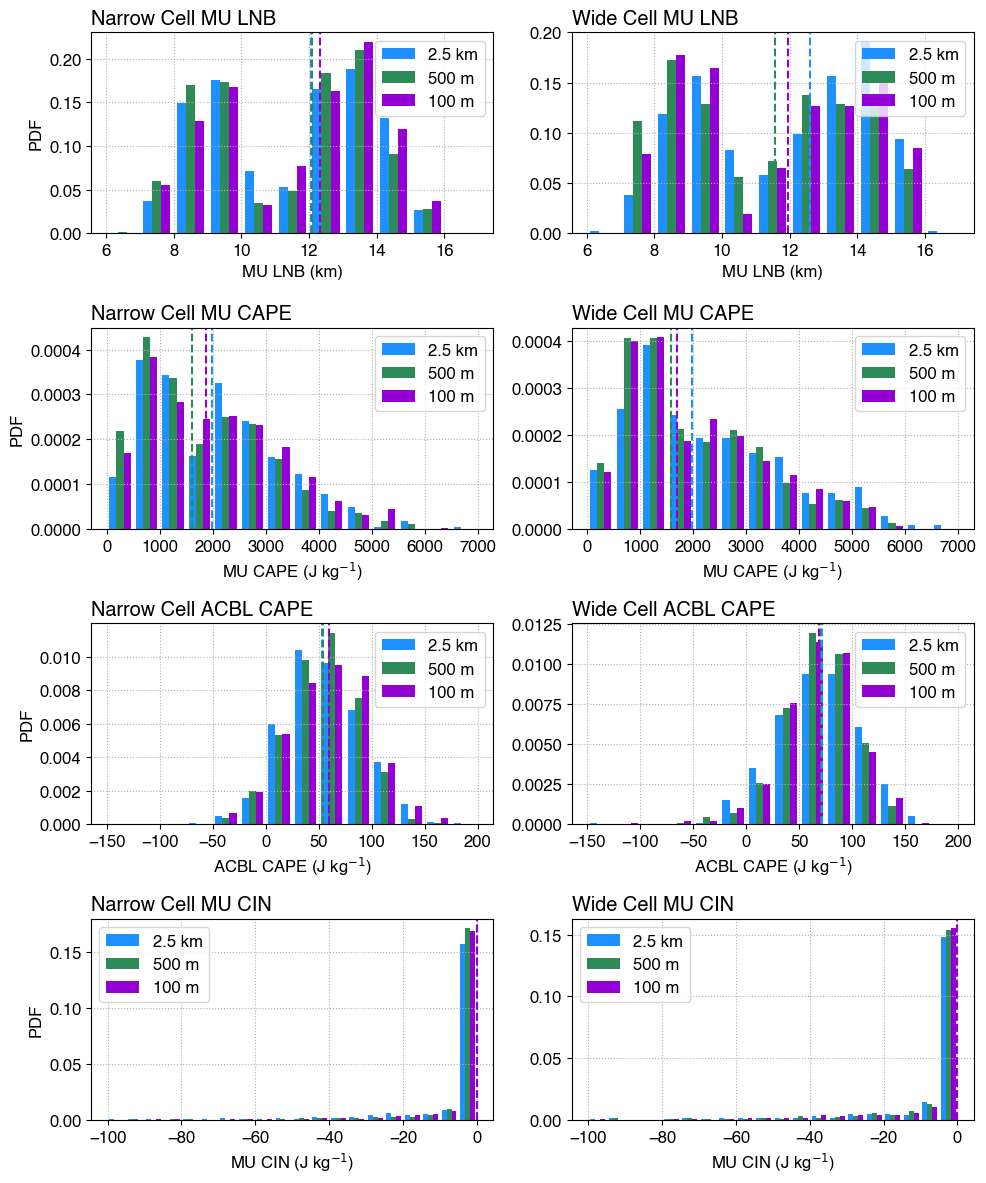

In [45]:
preCI_t = -3  # preCI time to get a single value

bins_EL = np.arange(6,17.1,1)
bins_CAPE = np.arange(0, 7001, 500)
bins_CAPEacbl = np.arange(-150, 201, 25)
bins_CIN = np.arange(-100, 0.1, 5)
hist_bins = [
    [bins_EL] * 2,
    [bins_CAPE] * 2,
    [bins_CAPEacbl] * 2,
    [bins_CIN] * 2,
]
data_arr = [
    [[narrow_pELmu_d2.sel(times=preCI_t), narrow_pELmu_d3.sel(times=preCI_t), narrow_pELmu_d4.sel(times=preCI_t)],
     [wide_pELmu_d2.sel(times=preCI_t), wide_pELmu_d3.sel(times=preCI_t), wide_pELmu_d4.sel(times=preCI_t)]],
    [[narrow_pCAPEmu_d2.sel(times=preCI_t), narrow_pCAPEmu_d3.sel(times=preCI_t), narrow_pCAPEmu_d4.sel(times=preCI_t)],
     [wide_pCAPEmu_d2.sel(times=preCI_t), wide_pCAPEmu_d3.sel(times=preCI_t), wide_pCAPEmu_d4.sel(times=preCI_t)]],
    [[narrow_pCAPEacbl_d2.sel(times=preCI_t), narrow_pCAPEacbl_d3.sel(times=preCI_t), narrow_pCAPEacbl_d4.sel(times=preCI_t)],
     [wide_pCAPEacbl_d2.sel(times=preCI_t), wide_pCAPEacbl_d3.sel(times=preCI_t), wide_pCAPEacbl_d4.sel(times=preCI_t)]],
    [[narrow_pCINmu_d2.sel(times=preCI_t), narrow_pCINmu_d3.sel(times=preCI_t), narrow_pCINmu_d4.sel(times=preCI_t)],
     [wide_pCINmu_d2.sel(times=preCI_t), wide_pCINmu_d3.sel(times=preCI_t), wide_pCINmu_d4.sel(times=preCI_t)]],
]
titles = [
    ['Narrow Cell MU LNB','Wide Cell MU LNB'], 
    ['Narrow Cell MU CAPE','Wide Cell MU CAPE'], 
    ['Narrow Cell ACBL CAPE', 'Wide Cell ACBL CAPE'],
    ['Narrow Cell MU CIN', 'Wide Cell MU CIN'],
]
xlabels = [['MU LNB (km)']*2, ['MU CAPE (J kg$^{-1}$)']*2, ['ACBL CAPE (J kg$^{-1}$)']*2, ['MU CIN (J kg$^{-1}$)']*2]
ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ['PDF','']]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 12
figsize = (10, 12)
figname = f'{figdir}PDF_NarrowWide_pEL_pCAPE_pCIN_d2_d3_d4.png'
fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

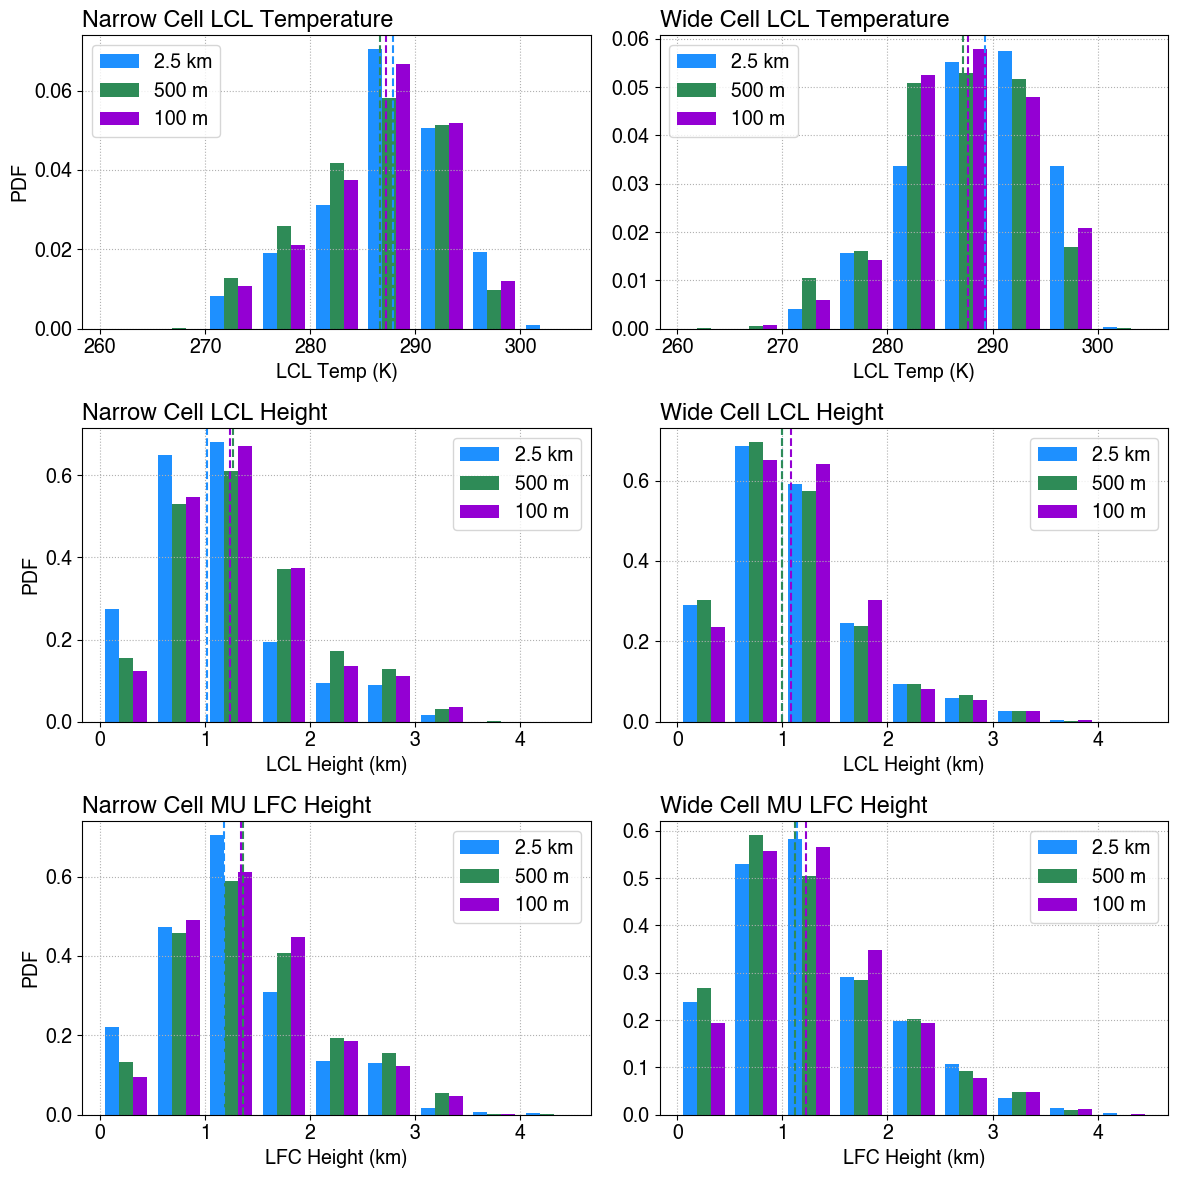

In [46]:
preCI_t = -3  # preCI time to get a single value

bins_LCLz = np.arange(0, 4.6, 0.5)
bins_LCLt = np.arange(260, 305.1, 5)
bins_LFCz = np.arange(0, 4.6, 0.5)
hist_bins = [
    [bins_LCLt] * 2,
    [bins_LCLz] * 2,
    [bins_LFCz] * 2,
]
data_arr = [
    [[narrow_LCLt_d2.sel(times=preCI_t), narrow_LCLt_d3.sel(times=preCI_t), narrow_LCLt_d4.sel(times=preCI_t)],
     [wide_LCLt_d2.sel(times=preCI_t), wide_LCLt_d3.sel(times=preCI_t), wide_LCLt_d4.sel(times=preCI_t)]],
    [[narrow_LCLz_d2.sel(times=preCI_t), narrow_LCLz_d3.sel(times=preCI_t), narrow_LCLz_d4.sel(times=preCI_t)],
     [wide_LCLz_d2.sel(times=preCI_t), wide_LCLz_d3.sel(times=preCI_t), wide_LCLz_d4.sel(times=preCI_t)]],
    [[narrow_pLFCz_d2.sel(times=preCI_t), narrow_pLFCz_d3.sel(times=preCI_t), narrow_pLFCz_d4.sel(times=preCI_t)],
     [wide_pLFCz_d2.sel(times=preCI_t), wide_pLFCz_d3.sel(times=preCI_t), wide_pLFCz_d4.sel(times=preCI_t)]],
]
titles = [
    ['Narrow Cell LCL Temperature','Wide Cell LCL Temperature'], 
    ['Narrow Cell LCL Height','Wide Cell LCL Height'], 
    ['Narrow Cell MU LFC Height', 'Wide Cell MU LFC Height'],
]
xlabels = [['LCL Temp (K)']*2, ['LCL Height (km)']*2, ['LFC Height (km)']*2, ]
ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}PDF_NarrowWide_LCL_pLFC_d2_d3_d4.png'
fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

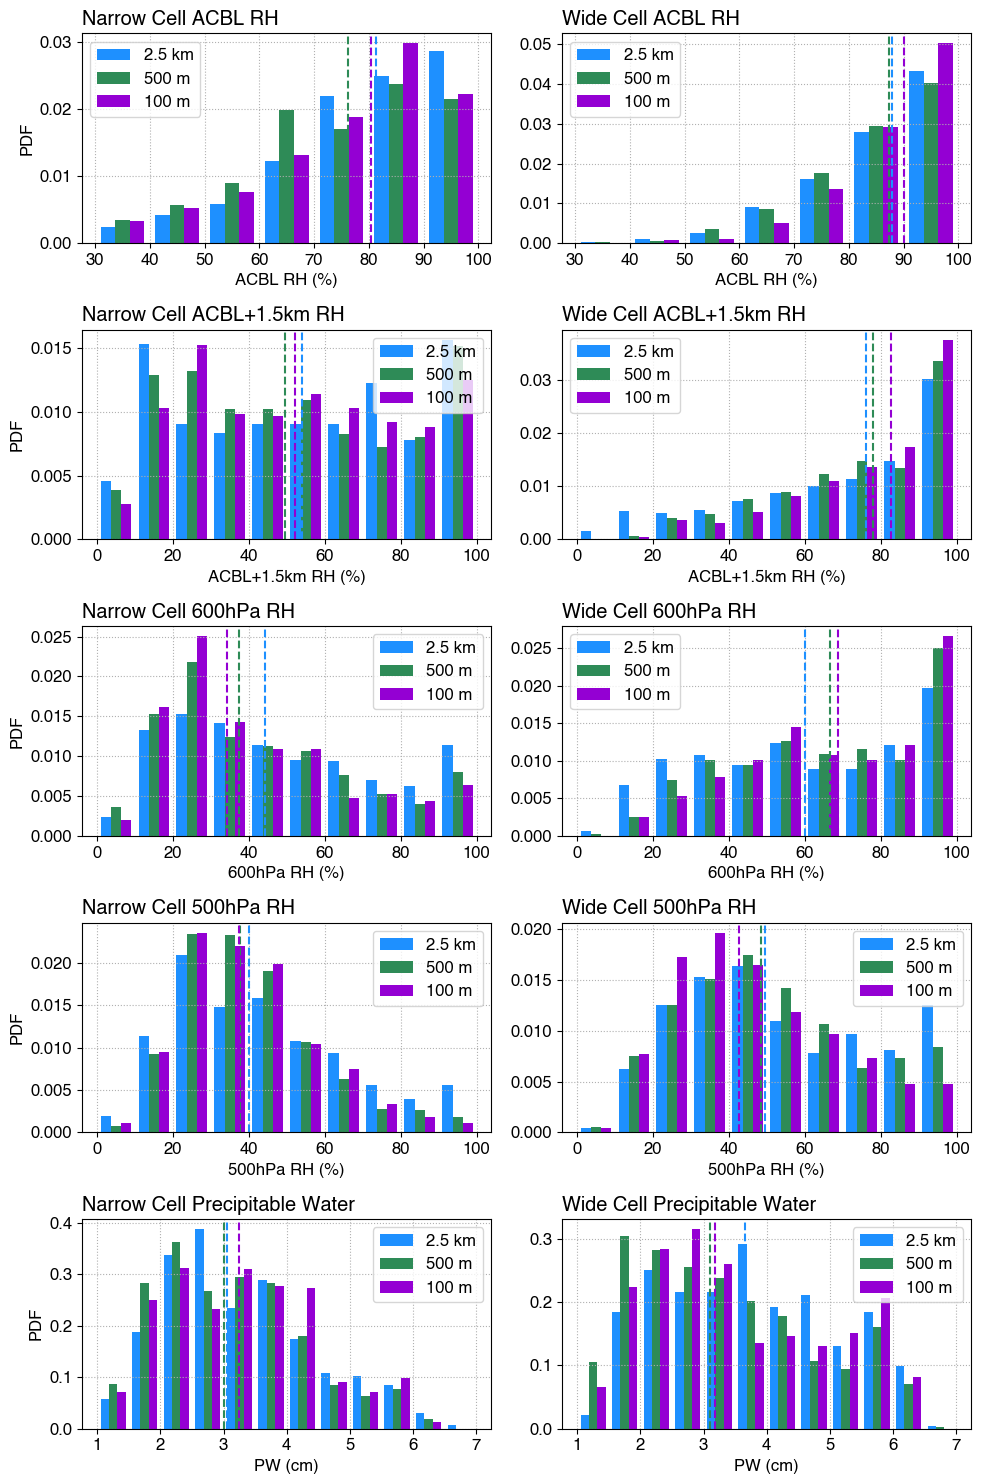

In [47]:
preCI_t = -3  # preCI time to get a single value

bins_RHacbl = np.arange(30, 101, 10)
bins_RH600 = np.arange(0, 101, 10)
bins_PW = np.arange(1, 7.1, 0.5)
hist_bins = [
    [bins_RHacbl] * 2,
    [bins_RH600] * 2,
    [bins_RH600] * 2,
    [bins_RH600] * 2,
    [bins_PW] * 2,
]
data_arr = [
    [[narrow_RHacbl_d2.sel(times=preCI_t), narrow_RHacbl_d3.sel(times=preCI_t), narrow_RHacbl_d4.sel(times=preCI_t)],
     [wide_RHacbl_d2.sel(times=preCI_t), wide_RHacbl_d3.sel(times=preCI_t), wide_RHacbl_d4.sel(times=preCI_t)]],
    [[narrow_RHlfc1500_d2.sel(times=preCI_t), narrow_RHlfc1500_d3.sel(times=preCI_t), narrow_RHlfc1500_d4.sel(times=preCI_t)],
     [wide_RHlfc1500_d2.sel(times=preCI_t), wide_RHlfc1500_d3.sel(times=preCI_t), wide_RHlfc1500_d4.sel(times=preCI_t)]],
    [[narrow_RH600mb_d2.sel(times=preCI_t), narrow_RH600mb_d3.sel(times=preCI_t), narrow_RH600mb_d4.sel(times=preCI_t)],
     [wide_RH600mb_d2.sel(times=preCI_t), wide_RH600mb_d3.sel(times=preCI_t), wide_RH600mb_d4.sel(times=preCI_t)]],
    [[narrow_RH500mb_d2.sel(times=preCI_t), narrow_RH500mb_d3.sel(times=preCI_t), narrow_RH500mb_d4.sel(times=preCI_t)],
     [wide_RH500mb_d2.sel(times=preCI_t), wide_RH500mb_d3.sel(times=preCI_t), wide_RH500mb_d4.sel(times=preCI_t)]],
    [[narrow_PW_d2.sel(times=preCI_t), narrow_PW_d3.sel(times=preCI_t), narrow_PW_d4.sel(times=preCI_t)],
     [wide_PW_d2.sel(times=preCI_t), wide_PW_d3.sel(times=preCI_t), wide_PW_d4.sel(times=preCI_t)]],
]
titles = [
    ['Narrow Cell ACBL RH','Wide Cell ACBL RH'], 
    ['Narrow Cell ACBL+1.5km RH','Wide Cell ACBL+1.5km RH'], 
    ['Narrow Cell 600hPa RH','Wide Cell 600hPa RH'], 
    ['Narrow Cell 500hPa RH', 'Wide Cell 500hPa RH'],
    ['Narrow Cell Precipitable Water', 'Wide Cell Precipitable Water'],
]
xlabels = [['ACBL RH (%)']*2, ['ACBL+1.5km RH (%)']*2, ['600hPa RH (%)']*2, ['500hPa RH (%)']*2, ['PW (cm)']*2]
ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ['PDF',''], ['PDF','']]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 12
figsize = (10, 15)
figname = f'{figdir}PDF_NarrowWide_RH_PW_d2_d3_d4.png'
fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

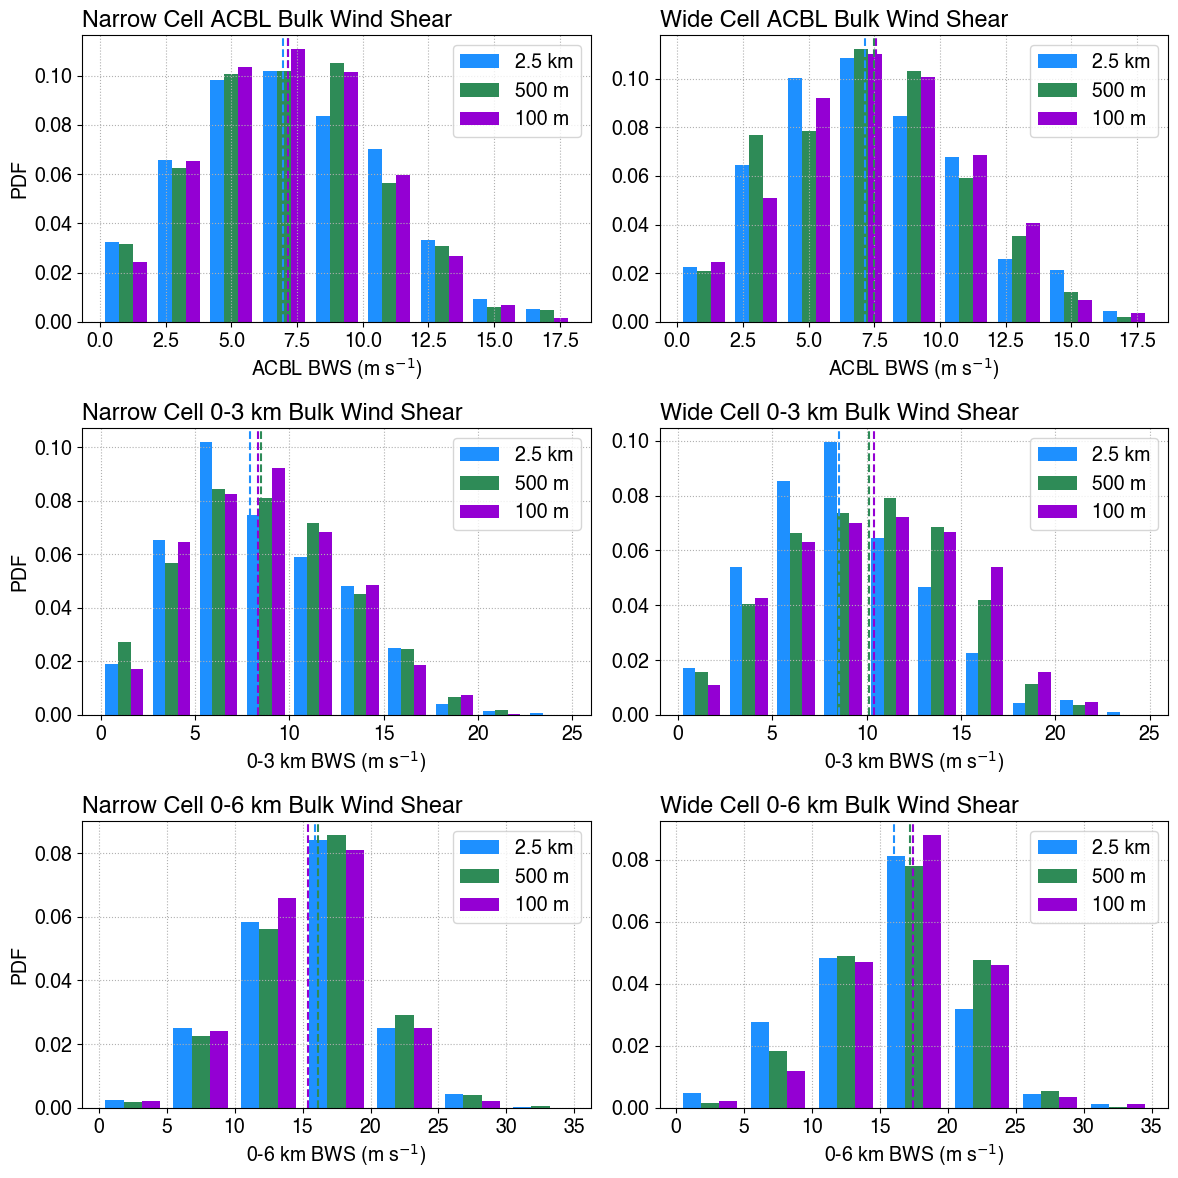

In [48]:
preCI_t = -3  # preCI time to get a single value

bins_BWSacbl = np.arange(0, 18.1, 2)
bins_BWS03km = np.arange(0, 25.1, 2.5)
bins_BWS06km = np.arange(0, 35.1, 5)
hist_bins = [
    [bins_BWSacbl] * 2,
    [bins_BWS03km] * 2,
    [bins_BWS06km] * 2,
]
data_arr = [
    [[narrow_BWSacbl_d2.sel(times=preCI_t), narrow_BWSacbl_d3.sel(times=preCI_t), narrow_BWSacbl_d4.sel(times=preCI_t)],
     [wide_BWSacbl_d2.sel(times=preCI_t), wide_BWSacbl_d3.sel(times=preCI_t), wide_BWSacbl_d4.sel(times=preCI_t)]],
    [[narrow_BWS03km_d2.sel(times=preCI_t), narrow_BWS03km_d3.sel(times=preCI_t), narrow_BWS03km_d4.sel(times=preCI_t)],
     [wide_BWS03km_d2.sel(times=preCI_t), wide_BWS03km_d3.sel(times=preCI_t), wide_BWS03km_d4.sel(times=preCI_t)]],
    [[narrow_BWS06km_d2.sel(times=preCI_t), narrow_BWS06km_d3.sel(times=preCI_t), narrow_BWS06km_d4.sel(times=preCI_t)],
     [wide_BWS06km_d2.sel(times=preCI_t), wide_BWS06km_d3.sel(times=preCI_t), wide_BWS06km_d4.sel(times=preCI_t)]],
]
titles = [
    ['Narrow Cell ACBL Bulk Wind Shear','Wide Cell ACBL Bulk Wind Shear'], 
    ['Narrow Cell 0-3 km Bulk Wind Shear','Wide Cell 0-3 km Bulk Wind Shear'], 
    ['Narrow Cell 0-6 km Bulk Wind Shear', 'Wide Cell 0-6 km Bulk Wind Shear'],
]
xlabels = [['ACBL BWS (m s$^{-1}$)']*2, ['0-3 km BWS (m s$^{-1}$)']*2, ['0-6 km BWS (m s$^{-1}$)']*2, ]
ylabels = [['PDF',''], ['PDF',''], ['PDF',''], ]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

fontsize = 14
figsize = (12, 12)
figname = f'{figdir}PDF_NarrowWide_BWS_d2_d3_d4.png'
fig = plot_mxn_hist(nrow, ncol, data_arr, hist_bins, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [49]:
figname

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/PDF_NarrowWide_BWS_d2_d3_d4.png'